<a href="https://colab.research.google.com/github/FinancialWisdomAI/FinancialWisdomSimulator/blob/main/financial_wisdom_simulator_V2C_Organized_08_26_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Asset database loaded.

                         Asset  MeanReturn  StdDev
0           S&P 500 Index Fund      0.1185   0.194
1   60/40 Stock-Bond Portfolio      0.0800   0.120
2       Conservative Portfolio      0.0500   0.060
3                 US Large Cap      0.1185   0.194
4                 US Small Cap      0.1200   0.250
5         International Stocks      0.0850   0.170
6                        Bonds      0.0500   0.070
7                         Cash      0.0250   0.010
8                        REITs      0.1000   0.200
9                Growth Stocks      0.1300   0.230
10                Value Stocks      0.1100   0.180
11              Treasury Bonds      0.0400   0.050
12                        Gold      0.0600   0.150
Historical model loaded.
Return matrix shape: (118, 11)
Covariance matrix shape: (11, 11)
 Financial Wisdom Monte Carlo Simulator


Risk Tolerance
1 - Low
2 - Moderate
3 - High

 Enter Your Current Portfolio

Enter the percentage currently invested in each asse

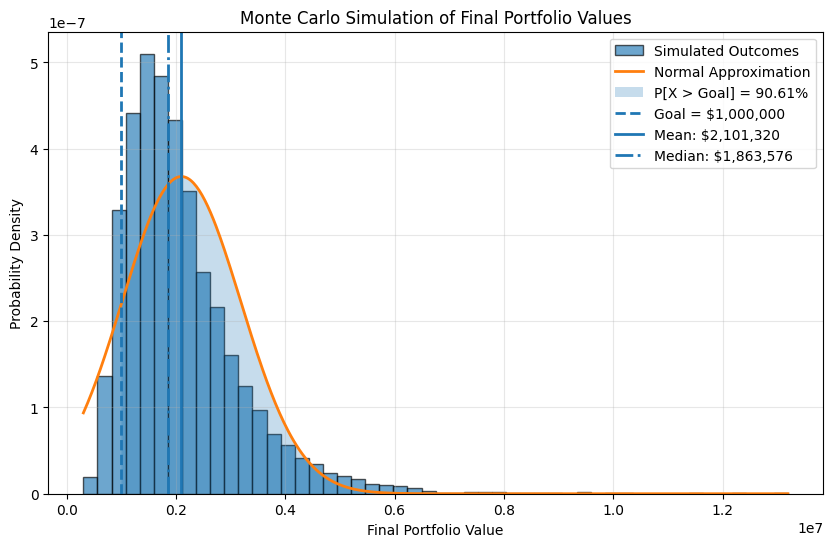

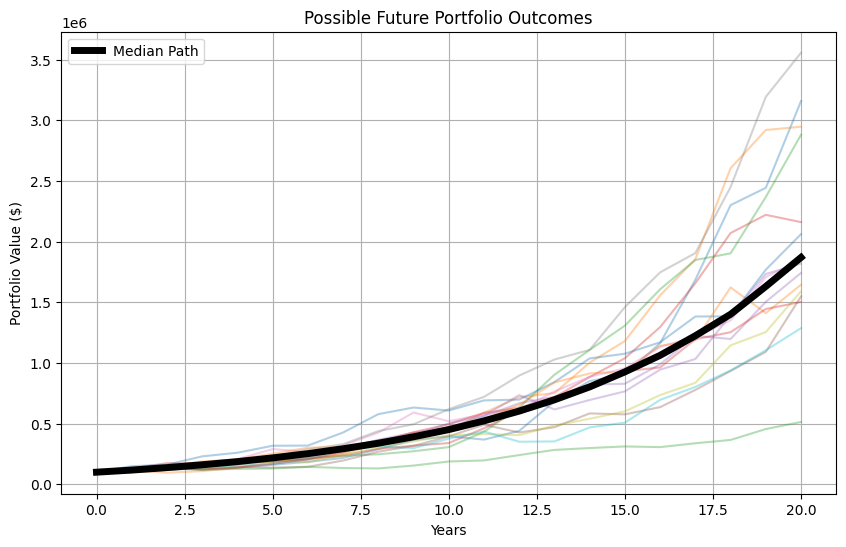

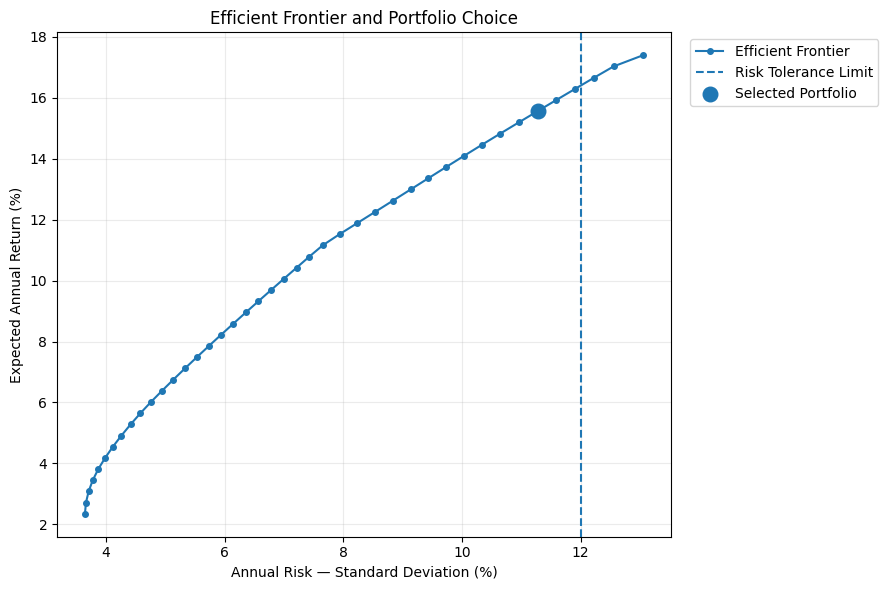


 Hidden Risk Structure

Dominant common market movement: 76.8%
Gold-related movement: 15.8%
Growth vs. value / real-asset movement: 6.1%
Other independent movements: 1.2%

The first three movement patterns explain 98.8%
of the historical variance in this portfolio.

What do I know?
About 76.8% of this portfolio's historical variance
is associated with one dominant pattern of market movement.

What does it mean?
Several investments may have different names
but still respond to some of the same underlying market forces.
Other investments participate in different movement patterns.
Those differences can help reduce dependence on a single source
of market movement.

Financial Wisdom:
Diversification is not simply owning more investments.
It comes from combining investments that do not all behave
the same way under changing market conditions.

Historical relationships can change.
PCA describes the data we observed; it does not predict
future market behavior.


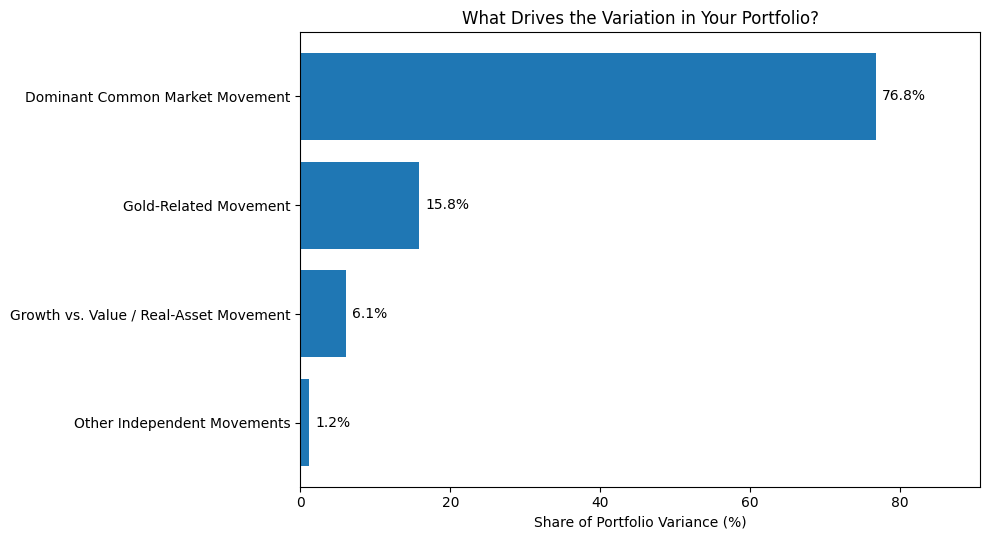

In [8]:
# ============================================================
# FINANCIAL WISDOM MONTE CARLO SIMULATOR
# Organized single-cell Colab version
#
# Program flow:
#   1. Imports and configuration
#   2. User input and validation
#   3. Asset definitions and historical data
#   4. Monte Carlo simulation and statistical summaries
#   5. Portfolio mathematics and optimization
#   6. Financial Wisdom interpretation
#   7. Reporting and graphics
#   8. PCA hidden-risk analysis
#   9. Goal-rescue calculations
#  10. Future-model placeholders
#  11. Main program
#
# The validated algorithms are preserved; this version only
# reorganizes code order, removes duplicate imports/definitions,
# and adds explanatory section comments.
# ============================================================


# ============================================================
# 1. IMPORTS AND CONFIGURATION
# ============================================================
# All external dependencies and global configuration values are
# defined before any simulator functions.

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from scipy.optimize import minimize
from scipy.stats import norm
from scipy.stats import binom
from scipy.special import gammaln, logsumexp
import math

DEFAULT_NUM_SIMULATIONS = 10_000
RANDOM_SEED = 42
MIN_ANNUAL_RETURN = -0.99

# ------------------------------------------------------------
# Development / research controls
# ------------------------------------------------------------

SHOW_RESEARCH_DIAGNOSTICS = False


# ============================================================
# 2. USER INPUT AND VALIDATION
# ============================================================
# All keyboard input and validation helpers are grouped together.
# main() can therefore focus on coordinating the investment workflow.

def _quit_if_requested(response: str) -> None:
    if response.lower() in ["q", "quit", "exit"]:
        print("\nExiting Financial Wisdom Simulator.")
        sys.exit()

def get_money(prompt: str, min_value=None, allow_zero=True) -> float:
    while True:
        response = input(prompt).strip()
        _quit_if_requested(response)
        try:
            value = float(response.replace('$', '').replace(',', ''))

            if min_value is not None and value < min_value:
                  print(f"Please enter an amount of at least ${min_value:,.0f}.")
                  continue

            if not allow_zero and value == 0:
                  print("Please enter an amount greater than $0.")
                  continue

            return value
        except ValueError:
            print("Please enter a valid dollar amount. Examples: 1000, 1,000, $1,000. Type 'q' to quit.")

def get_integer(prompt: str,min_value=None,max_value=None,allow_zero=True) -> int:
    while True:
        response = input(prompt).strip()
        _quit_if_requested(response)

        try:
            value = int(response.replace('$', '').replace(',', ''))

            if min_value is not None and value < min_value:
                print(f"Please enter a value of at least {min_value}.")
                continue

            if max_value is not None and value > max_value:
                print(f"Please enter a value no greater than {max_value}.")
                continue

            if not allow_zero and value == 0:
                print("Please enter a value greater than 0.")
                continue

            return value

        except ValueError:
            print("Please enter a whole number. Examples: 10000 or 10,000. Type 'q' to quit.")

def get_float(prompt, min_value=None, max_value=None,default=None):
    while True:
        try:
            response = input(prompt).strip()
            _quit_if_requested(response)


            if response == "" and default is not None:
                return default

            value = float(response)

            if min_value is not None and value < min_value:
                print(
                    f"Please enter a value of at least "
                    f"{min_value}."
                )
                continue

            if max_value is not None and value > max_value:
                print(
                    f"Please enter a value no greater than "
                    f"{max_value}."
                )
                continue

            return value

        except ValueError:
            print("Please enter a valid number.")

def get_yes_no(prompt: str) -> str:
    while True:
        response = input(prompt).strip().lower()
        _quit_if_requested(response)
        if response in ["yes", "y"]:
            return "Yes"
        if response in ["no", "n"]:
            return "No"
        print("Please answer Yes or No. Examples: yes, y, no, n. Type 'q' to quit.")

def collect_user_plan() -> dict:
    print("=====================================")
    print(" Financial Wisdom Monte Carlo Simulator")
    print("======================================\n")

    plan = {}

    response = input(
       "What is your financial goal? "
    ).strip()
    _quit_if_requested(response)
    plan["goal_name"] = response

    plan["goal_amount"] = get_money(
       "What is your goal amount ($)? ",
       min_value=0,
       allow_zero=False
    )

    plan["years"] = get_integer(
       "How many years until you need the money? ",
       min_value=1
    )

    plan["initial_balance"] = get_money(
       "Initial investment amount ($): ",
       min_value=0
    )

    if plan["initial_balance"] >= plan["goal_amount"]:
       print("\nYour initial investment already meets or exceeds your stated goal.")
       print(f"Goal Amount: ${plan['goal_amount']:,.2f}")
       print(f"Initial Investment: ${plan['initial_balance']:,.2f}")
       print("\nPlease check your entries before continuing.")

    plan["monthly_contribution"] = get_money(
       "Monthly contribution ($): ",
       min_value=0
    )

    return plan


# ============================================================
# 3. ASSET DEFINITIONS AND HISTORICAL DATA
# ============================================================
# ASSET_DATA contains the simulator assumptions for predefined choices.
# ASSET_PROXIES maps asset classes to ETF proxies used for historical
# return, correlation, and covariance estimates.

ASSET_DATA = [
    {"Asset": "S&P 500 Index Fund", "MeanReturn": 0.1185, "StdDev": 0.194},
    {"Asset": "60/40 Stock-Bond Portfolio", "MeanReturn": 0.0800, "StdDev": 0.120},
    {"Asset": "Conservative Portfolio", "MeanReturn": 0.0500, "StdDev": 0.060},
    {"Asset": "US Large Cap", "MeanReturn": 0.1185, "StdDev": 0.194},
    {"Asset": "US Small Cap", "MeanReturn": 0.1200, "StdDev": 0.250},
    {"Asset": "International Stocks", "MeanReturn": 0.0850, "StdDev": 0.170},
    {"Asset": "Bonds", "MeanReturn": 0.0500, "StdDev": 0.070},
    {"Asset": "Cash", "MeanReturn": 0.0250, "StdDev": 0.010},
    {"Asset": "REITs", "MeanReturn": 0.1000, "StdDev": 0.200},
    {"Asset": "Growth Stocks", "MeanReturn": 0.1300, "StdDev": 0.230},
    {"Asset": "Value Stocks", "MeanReturn": 0.1100, "StdDev": 0.180},
    {"Asset": "Treasury Bonds", "MeanReturn": 0.0400, "StdDev": 0.050},
    {"Asset": "Gold", "MeanReturn": 0.0600, "StdDev": 0.150},
]

ASSET_PROXIES = {
    "S&P 500 Index Fund": "VOO",
    "US Large Cap": "VOO",
    "US Small Cap": "VB",
    "International Stocks": "VXUS",
    "Bonds": "BND",
    "Cash": "BIL",
    "REITs": "VNQ",
    "Growth Stocks": "VUG",
    "Value Stocks": "VTV",
    "Treasury Bonds": "IEF",
    "Gold": "GLD",
}

def load_asset_database() -> pd.DataFrame:
    return pd.DataFrame(ASSET_DATA)

def download_historical_data():

    tickers = sorted(set(ASSET_PROXIES.values()))

    data = yf.download(
        tickers,
        period="10y",
        interval="1mo",
        auto_adjust=True,
        progress=False
    )

    prices = data["Close"].copy()

    # Remove incomplete current month
    today = pd.Timestamp.today()
    current_month_start = (
        today.to_period("M").to_timestamp()
    )

    prices = prices[
        prices.index < current_month_start
    ].copy()

    return prices

def calculate_returns(prices):
    returns = prices.pct_change()
    return returns.dropna()

def calculate_statistics(returns):
    mean_returns = returns.mean()
    std_returns = returns.std()
    correlation_matrix = returns.corr()
    covariance_matrix = returns.cov()

    return (
        mean_returns,
        std_returns,
        correlation_matrix,
        covariance_matrix
    )

def build_historical_model():

    prices = download_historical_data()

    returns = calculate_returns(prices)

    asset_returns = pd.DataFrame(
        index=returns.index
    )

    for asset_name, ticker in ASSET_PROXIES.items():
        asset_returns[asset_name] = returns[ticker]

    (
        mean_returns,
        std_returns,
        correlation_matrix,
        covariance_matrix
    ) = calculate_statistics(asset_returns)

    return (
        asset_returns,
        mean_returns,
        std_returns,
        correlation_matrix,
        covariance_matrix
    )


# ============================================================
# 4. MONTE CARLO SIMULATION AND STATISTICAL SUMMARIES
# ============================================================
# These routines generate possible portfolio futures and reduce them
# to the summary statistics used throughout the simulator.

def simulate_portfolio(initial_balance: float, monthly_contribution: float, years: int,
                       mean_return: float, std_return: float, num_simulations: int,
                       min_annual_return: float = -0.99, random_seed=None) -> np.ndarray:
    rng = np.random.default_rng(random_seed)
    final_values = []

    for _ in range(num_simulations):
        balance = initial_balance
        for _ in range(years):
            annual_return = max(rng.normal(mean_return, std_return), min_annual_return)
            monthly_return = (1 + annual_return) ** (1 / 12) - 1
            if abs(monthly_return) < 1e-12:
                yearly_contribution_value = monthly_contribution * 12
            else:
                yearly_contribution_value = monthly_contribution * (((1 + monthly_return) ** 12 - 1) / monthly_return)
            balance = balance * (1 + annual_return) + yearly_contribution_value
        final_values.append(balance)

    return np.array(final_values)

def summarize_results(final_values, goal: float) -> dict:
    return {
        "mean_final": float(np.mean(final_values)),
        "median_final": float(np.median(final_values)),
        "std_final": float(np.std(final_values)),
        "prob_success": float(np.mean(final_values > goal)),
        "p10": float(np.percentile(final_values, 10)),
        "p25": float(np.percentile(final_values, 25)),
        "p75": float(np.percentile(final_values, 75)),
        "p90": float(np.percentile(final_values, 90)),
    }

def compare_paired_goal_outcomes(
    immediate_success,
    gradual_success
):

    # --------------------------------------------------------
    # Convert inputs to Boolean NumPy arrays.
    # --------------------------------------------------------

    immediate_success = np.asarray(
        immediate_success,
        dtype=bool
    )

    gradual_success = np.asarray(
        gradual_success,
        dtype=bool
    )

    # --------------------------------------------------------
    # Both arrays must contain the same number of
    # simulations because the observations are paired.
    # --------------------------------------------------------

    if immediate_success.shape != gradual_success.shape:

        raise ValueError(
            "Paired strategy outcome arrays "
            "must have the same shape."
        )

    n = immediate_success.size

    if n == 0:

        raise ValueError(
            "Paired strategy outcome arrays "
            "cannot be empty."
        )

    # --------------------------------------------------------
    # Construct the four paired outcome counts.
    #
    # n_11: both strategies succeed
    # n_10: Immediate succeeds, Gradual fails
    # n_01: Gradual succeeds, Immediate fails
    # n_00: both strategies fail
    # --------------------------------------------------------

    n_11 = int(
        np.sum(
            immediate_success
            & gradual_success
        )
    )

    n_10 = int(
        np.sum(
            immediate_success
            & ~gradual_success
        )
    )

    n_01 = int(
        np.sum(
            ~immediate_success
            & gradual_success
        )
    )

    n_00 = int(
        np.sum(
            ~immediate_success
            & ~gradual_success
        )
    )

    # --------------------------------------------------------
    # Goal-success probabilities.
    # --------------------------------------------------------

    immediate_probability = float(
        np.mean(immediate_success)
    )

    gradual_probability = float(
        np.mean(gradual_success)
    )

    probability_difference = (
        immediate_probability
        - gradual_probability
    )

    # --------------------------------------------------------
    # Discordant pairs.
    #
    # These are the paths on which the strategies
    # produce different goal outcomes.
    # --------------------------------------------------------

    discordant_pairs = (
        n_10 + n_01
    )

    # --------------------------------------------------------
    # McNemar chi-square statistic.
    #
    # If there are no discordant pairs, the strategies
    # produced identical success/failure outcomes.
    # --------------------------------------------------------

    if discordant_pairs == 0:

        mcnemar_chi_square = 0.0

    else:

        mcnemar_chi_square = (
            (n_10 - n_01) ** 2
            / discordant_pairs
        )

    # --------------------------------------------------------
    # Exact McNemar p-value.
    #
    # Under the null hypothesis, each discordant pair
    # is equally likely to favor either strategy.
    #
    # Therefore:
    #
    # n_10 | discordant_pairs
    #     ~ Binomial(discordant_pairs, 0.5)
    #
    # The two-sided exact p-value measures how likely
    # an imbalance at least this extreme would be if
    # neither strategy had an advantage.
    # --------------------------------------------------------

    if discordant_pairs == 0:

        exact_p_value = 1.0

    else:

        smaller_discordant_count = min(
            n_10,
            n_01
        )

        exact_p_value = (
            2.0
            * binom.cdf(
                smaller_discordant_count,
                discordant_pairs,
                0.5
            )
        )

        exact_p_value = min(
            exact_p_value,
            1.0
        )




    # --------------------------------------------------------
    # Numerically stable log-space exact McNemar p-value.
    #
    # For the two-sided exact test:
    #
    # p = 2 * sum from k=0 to m of
    #     C(M,k) * (0.5)^M
    #
    # where:
    #
    # M = number of discordant pairs
    # m = smaller discordant count
    #
    # The calculation is performed entirely in
    # logarithmic space to prevent numerical underflow.
    # --------------------------------------------------------

    if discordant_pairs == 0:

        log10_exact_p_value = 0.0

    else:

        k_values = np.arange(
            smaller_discordant_count + 1
        )

        log_binomial_coefficients = (
            gammaln(discordant_pairs + 1)
            - gammaln(k_values + 1)
            - gammaln(
                discordant_pairs
                - k_values
                + 1
            )
        )

        log_terms = (
            log_binomial_coefficients
            - discordant_pairs
            * math.log(2.0)
        )

        log_one_tail = logsumexp(
            log_terms
        )

        log_two_tail = (
            math.log(2.0)
            + log_one_tail
        )

        log10_exact_p_value = (
            log_two_tail
            / math.log(10.0)
        )



    # --------------------------------------------------------
    # Return the paired comparison.
    #
    # Exact binomial p-value will be added after the
    # paired-count and chi-square calculations have
    # been independently validated.
    # --------------------------------------------------------

    return {
        "n": n,
        "n_11": n_11,
        "n_10": n_10,
        "n_01": n_01,
        "n_00": n_00,
        "discordant_pairs": discordant_pairs,
        "immediate_probability":
            immediate_probability,
        "gradual_probability":
            gradual_probability,
        "probability_difference":
            float(probability_difference),
        "mcnemar_chi_square":
            float(mcnemar_chi_square),
        "degrees_of_freedom":
            1,
        "exact_p_value":
            float(exact_p_value),
        "log10_exact_p_value":
            float(log10_exact_p_value),
    }

def classify_goal_probability(
    goal_probability,
    num_simulations,
    required_probability=0.90,
    z=1.96
):

    # --------------------------------------------------------
    # Wilson confidence interval for a Monte Carlo
    # estimate of goal probability.
    # --------------------------------------------------------

    p_hat = float(goal_probability)
    n = int(num_simulations)

    if n <= 0:
        raise ValueError(
            "Number of simulations must be positive."
        )

    if not 0.0 <= p_hat <= 1.0:
        raise ValueError(
            "Goal probability must be between 0 and 1."
        )

    denominator = (
        1.0 + (z ** 2) / n
    )

    center = (
        p_hat + (z ** 2) / (2.0 * n)
    )

    margin = (
        z
        * np.sqrt(
            (
                p_hat * (1.0 - p_hat) / n
            )
            +
            (
                z ** 2 / (4.0 * n ** 2)
            )
        )
    )

    lower_bound = (
        (center - margin)
        / denominator
    )

    upper_bound = (
        (center + margin)
        / denominator
    )

    # --------------------------------------------------------
    # Financial Wisdom three-zone classification
    # --------------------------------------------------------

    if lower_bound >= required_probability:

        classification = (
            "Clearly Meets Goal Standard"
        )

    elif upper_bound < required_probability:

        classification = (
            "Clearly Below Goal Standard"
        )

    else:

        classification = (
            "Near Threshold - Uncertain"
        )

    return {
        "goal_probability": p_hat,
        "lower_bound": float(lower_bound),
        "upper_bound": float(upper_bound),
        "required_probability": float(
            required_probability
        ),
        "classification": classification,
    }

def evaluate_portfolio_status(
    goal_probability,
    annual_risk,
    risk_tolerance,
    num_simulations,
    required_probability=0.90
):

    # --------------------------------------------------------
    # Determine the investor's maximum permitted risk.
    # --------------------------------------------------------

    risk_limits = {
        1: 0.08,
        2: 0.12,
        3: 0.18
    }

    if risk_tolerance not in risk_limits:
        raise ValueError(
            "Risk tolerance must be 1, 2, or 3."
        )

    risk_limit = risk_limits[
        risk_tolerance
    ]

    # --------------------------------------------------------
    # Evaluate goal probability using the Wilson interval.
    # --------------------------------------------------------

    goal_result = classify_goal_probability(
        goal_probability=goal_probability,
        num_simulations=num_simulations,
        required_probability=required_probability
    )

    # --------------------------------------------------------
    # Evaluate portfolio risk.
    # --------------------------------------------------------

    if annual_risk <= risk_limit:
        risk_classification = (
            "Within Risk Limit"
        )
    else:
        risk_classification = (
            "Above Risk Limit"
        )




    # --------------------------------------------------------
    # Determine whether portfolio review is indicated.
    # This does NOT recommend a trade or rebalancing action.
    # --------------------------------------------------------

    goal_classification = (
        goal_result["classification"]
    )

    if (
        goal_classification
        == "Clearly Meets Goal Standard"
        and annual_risk <= risk_limit
    ):

        review_status = (
            "No Immediate Portfolio Review Indicated"
        )

    elif (
        goal_classification
        == "Clearly Meets Goal Standard"
        and annual_risk > risk_limit
    ):

        review_status = (
            "Review - Risk Exceeds Investor Limit"
        )

    elif (
        goal_classification
        == "Near Threshold - Uncertain"
        and annual_risk <= risk_limit
    ):

        review_status = (
            "Review - Goal Probability Near Threshold"
        )

    elif (
        goal_classification
        == "Near Threshold - Uncertain"
        and annual_risk > risk_limit
    ):

        review_status = (
            "Review - Goal Uncertain and Risk Too High"
        )

    elif (
        goal_classification
        == "Clearly Below Goal Standard"
        and annual_risk <= risk_limit
    ):

        review_status = (
            "Review - Goal Inadequately Supported"
        )

    else:

        review_status = (
            "Strong Review - Goal Below Standard "
            "and Risk Too High"
        )

    # --------------------------------------------------------
    # Return the two assessments.
    # No rebalancing decision is made yet.
    # --------------------------------------------------------

    return {
        "goal_classification":
            goal_result["classification"],

        "goal_lower_bound":
            goal_result["lower_bound"],

        "goal_upper_bound":
            goal_result["upper_bound"],

        "annual_risk":
            float(annual_risk),

        "risk_limit":
            float(risk_limit),

        "risk_classification":
            risk_classification,

        "review_status":
            review_status,
    }

def calculate_contribution_rebalancing(
    current_weights,
    target_weights,
    portfolio_value,
    monthly_contribution
):

    # --------------------------------------------------------
    # Estimate whether the current portfolio can be moved
    # toward the target portfolio using new contributions
    # only -- without selling existing investments.
    #
    # Market returns are intentionally ignored here.
    # This provides a transparent baseline calculation.
    # --------------------------------------------------------

    if portfolio_value <= 0:
        raise ValueError(
            "Portfolio value must be positive."
        )

    if monthly_contribution <= 0:
        raise ValueError(
            "Monthly contribution must be positive."
        )

    # --------------------------------------------------------
    # Make sure both portfolios contain the same asset set.
    # Missing assets are assigned a weight of zero.
    # --------------------------------------------------------

    all_assets = set(
        current_weights.keys()
    ) | set(
        target_weights.keys()
    )

    current = {
        asset: float(
            current_weights.get(asset, 0.0)
        )
        for asset in all_assets
    }

    target = {
        asset: float(
            target_weights.get(asset, 0.0)
        )
        for asset in all_assets
    }

    # --------------------------------------------------------
    # Validate weights.
    # --------------------------------------------------------

    if not np.isclose(
        sum(current.values()),
        1.0
    ):
        raise ValueError(
            "Current portfolio weights must sum to 1.0."
        )

    if not np.isclose(
        sum(target.values()),
        1.0
    ):
        raise ValueError(
            "Target portfolio weights must sum to 1.0."
        )

    # --------------------------------------------------------
    # Determine minimum new money required.
    #
    # For each overweight asset:
    #
    # A_i / (V + C) <= target_weight_i
    #
    # Therefore:
    #
    # C >= A_i / target_weight_i - V
    # --------------------------------------------------------

    required_new_money = 0.0

    for asset in all_assets:

        current_weight = current[asset]
        target_weight = target[asset]

        if current_weight > target_weight:

            # Treat extremely small optimizer weights as zero.
            # Optimization routines may return values such as
            # 1e-18 when the mathematical solution is 0%.
            weight_tolerance = 1e-8

            if target_weight <= weight_tolerance:

                return {
                    "possible_with_contributions_only":
                        False,

                    "reason":
                        (
                            f"{asset} has a positive current "
                            f"allocation but essentially a zero "
                            f"target allocation."
                        )
                }

            current_asset_value = (
                current_weight
                * portfolio_value
            )

            money_needed = (
                current_asset_value
                / target_weight
                - portfolio_value
            )

            required_new_money = max(
                required_new_money,
                money_needed
            )

    # --------------------------------------------------------
    # Determine how long this would take.
    # --------------------------------------------------------

    months_required = (
        required_new_money
        / monthly_contribution
    )

    years_required = (
        months_required / 12.0
    )

    final_portfolio_value = (
        portfolio_value
        + required_new_money
    )

    # --------------------------------------------------------
    # Determine where the new contributions should go.
    # --------------------------------------------------------

    contribution_allocation = {}

    for asset in all_assets:

        current_asset_value = (
            current[asset]
            * portfolio_value
        )

        target_asset_value = (
            target[asset]
            * final_portfolio_value
        )

        contribution_needed = max(
            0.0,
            target_asset_value
            - current_asset_value
        )

        contribution_allocation[
            asset
        ] = contribution_needed

    return {
        "possible_with_contributions_only":
            True,

        "required_new_money":
            float(required_new_money),

        "months_required":
            float(months_required),

        "years_required":
            float(years_required),

        "contribution_allocation":
            contribution_allocation,
    }



def simulate_monthly_portfolio_strategy(
    initial_balance,
    monthly_contribution,
    years,
    current_weights,
    target_weights,
    mean_returns,
    covariance_matrix,
    num_simulations,
    random_seed=None,
    market_paths=None,
    market_assets=None,
    contribution_only=False,
    full_rebalance=False
):

    rng = np.random.default_rng(
        random_seed
    )

    if market_assets is not None:
        assets = list(market_assets)

    else:
        assets = list(
            dict.fromkeys(
                list(current_weights.keys())
                + list(target_weights.keys())
            )
        )

    missing_assets = [
        asset for asset in assets
        if (
            asset not in mean_returns.index
            or asset not in covariance_matrix.index
            or asset not in covariance_matrix.columns
        )
    ]

    if missing_assets:
        raise ValueError(
            f"Historical data missing for: "
            f"{missing_assets}"
        )

    current = np.array(
        [
            current_weights.get(asset, 0.0)
            for asset in assets
        ],
        dtype=float
    )

    target = np.array(
        [
            target_weights.get(asset, 0.0)
            for asset in assets
        ],
        dtype=float
    )

    if not np.isclose(current.sum(), 1.0):
        raise ValueError(
            "Current weights must sum to 1.0."
        )

    if not np.isclose(target.sum(), 1.0):
        raise ValueError(
            "Target weights must sum to 1.0."
        )

    monthly_means = (
        mean_returns
        .reindex(assets)
        .values
    )

    monthly_covariance = (
        covariance_matrix
        .reindex(
            index=assets,
            columns=assets
        )
        .values
    )

    number_of_months = years * 12

    final_values = np.zeros(
        num_simulations
    )

    for simulation in range(
        num_simulations
    ):

        asset_values = (
            current * initial_balance
        )

        for month in range(
            number_of_months
        ):

            if market_paths is not None:

                monthly_returns = (
                    market_paths[
                        simulation,
                        month,
                        :
                    ]
                )

            else:

                monthly_returns = (
                    rng.multivariate_normal(
                        monthly_means,
                        monthly_covariance
                    )
                )

                monthly_returns = np.maximum(
                    monthly_returns,
                    -0.99
                )

            # Apply monthly market returns
            asset_values = (
                asset_values
                * (1.0 + monthly_returns)
            )

            # Add this month's contribution
            if contribution_only:

                portfolio_value = (
                    asset_values.sum()
                    + monthly_contribution
                )

                target_values = (
                    target * portfolio_value
                )

                shortfalls = np.maximum(
                    0.0,
                    target_values - asset_values
                )

                total_shortfall = (
                    shortfalls.sum()
                )

                if total_shortfall > 0:

                    contribution_allocation = (
                        monthly_contribution
                        * shortfalls
                        / total_shortfall
                    )

                else:

                    contribution_allocation = (
                        monthly_contribution
                        * target
                    )

                asset_values += (
                    contribution_allocation
                )

            else:

                asset_values += (
                    monthly_contribution
                    * target
                )

            # Optional full rebalance
            if full_rebalance:

                total_value = (
                    asset_values.sum()
                )

                asset_values = (
                    target * total_value
                )

        final_values[
            simulation
        ] = asset_values.sum()

    return final_values




def calculate_contribution_adjusted_weights(
    current_weights,
    target_weights,
    portfolio_value,
    new_contribution
):

    # --------------------------------------------------------
    # Estimate portfolio weights after directing new money
    # toward assets that are underweight relative to the
    # target portfolio.
    #
    # No existing investments are sold.
    # --------------------------------------------------------

    if portfolio_value <= 0:
        raise ValueError(
            "Portfolio value must be positive."
        )

    if new_contribution < 0:
        raise ValueError(
            "New contribution cannot be negative."
        )

    all_assets = list(
        dict.fromkeys(
            list(current_weights.keys())
            + list(target_weights.keys())
        )
    )

    current = {
        asset: float(
            current_weights.get(asset, 0.0)
        )
        for asset in all_assets
    }

    target = {
        asset: float(
            target_weights.get(asset, 0.0)
        )
        for asset in all_assets
    }

    # --------------------------------------------------------
    # Validate portfolio weights.
    # --------------------------------------------------------

    if not np.isclose(
        sum(current.values()),
        1.0
    ):
        raise ValueError(
            "Current portfolio weights must sum to 1.0."
        )

    if not np.isclose(
        sum(target.values()),
        1.0
    ):
        raise ValueError(
            "Target portfolio weights must sum to 1.0."
        )

    # --------------------------------------------------------
    # Current dollar value of each asset.
    # --------------------------------------------------------

    asset_values = {
        asset:
            current[asset] * portfolio_value
        for asset in all_assets
    }

    final_portfolio_value = (
        portfolio_value + new_contribution
    )

    # --------------------------------------------------------
    # Determine each asset's dollar shortfall relative
    # to its target at the final portfolio value.
    # --------------------------------------------------------

    shortfalls = {}

    for asset in all_assets:

        target_value = (
            target[asset]
            * final_portfolio_value
        )

        shortfalls[asset] = max(
            0.0,
            target_value - asset_values[asset]
        )

    total_shortfall = sum(
        shortfalls.values()
    )

    # --------------------------------------------------------
    # Direct new money toward underweight assets in
    # proportion to their dollar shortfalls.
    # --------------------------------------------------------

    if total_shortfall > 0:

        for asset in all_assets:

            allocation = (
                new_contribution
                * shortfalls[asset]
                / total_shortfall
            )

            asset_values[asset] += allocation

    # --------------------------------------------------------
    # Calculate resulting portfolio weights.
    # --------------------------------------------------------

    adjusted_weights = {
        asset:
            asset_values[asset]
            / final_portfolio_value
        for asset in all_assets
    }

    return adjusted_weights




def generate_common_monthly_market_paths(
    assets,
    mean_returns,
    covariance_matrix,
    years,
    num_simulations,
    random_seed
):

    # --------------------------------------------------------
    # Generate common MONTHLY market paths for all strategies.
    #
    # Historical data is already monthly, so no annualization
    # is performed here.
    #
    # Shape:
    # (num_simulations, number_of_months, number_of_assets)
    # --------------------------------------------------------

    rng = np.random.default_rng(
        random_seed
    )

    assets = list(assets)

    # --------------------------------------------------------
    # Verify historical data exists for every asset.
    # --------------------------------------------------------

    missing_assets = [
        asset for asset in assets
        if (
            asset not in mean_returns.index
            or asset not in covariance_matrix.index
            or asset not in covariance_matrix.columns
        )
    ]

    if missing_assets:
        raise ValueError(
            f"Historical data missing for: "
            f"{missing_assets}"
        )

    # --------------------------------------------------------
    # Align monthly historical inputs.
    # --------------------------------------------------------

    monthly_means = (
        mean_returns
        .reindex(assets)
        .values
    )

    monthly_covariance = (
        covariance_matrix
        .reindex(
            index=assets,
            columns=assets
        )
        .values
    )

    number_of_months = (
        years * 12
    )

    # --------------------------------------------------------
    # Generate correlated monthly asset returns.
    # --------------------------------------------------------

    market_paths = (
        rng.multivariate_normal(
            mean=monthly_means,
            cov=monthly_covariance,
            size=(
                num_simulations,
                number_of_months
            )
        )
    )

    # --------------------------------------------------------
    # Prevent simulated monthly losses below -100%.
    # --------------------------------------------------------

    market_paths = np.maximum(
        market_paths,
        -0.99
    )

    return market_paths


# ============================================================
# 5. PORTFOLIO MATHEMATICS AND OPTIMIZATION
# ============================================================
# This section moves from portfolio return/risk calculations to the
# constrained frontier and goal-based portfolio selection.

def calculate_portfolio_statistics(
    weights,
    mean_returns,
    covariance_matrix
):

    weights = pd.Series(weights, dtype=float)
    selected_assets = weights.index

    missing_assets = [
        asset for asset in selected_assets
        if asset not in covariance_matrix.columns
    ]

    if missing_assets:
        raise ValueError(
            f"Historical data missing for: {missing_assets}"
        )

    if not np.isclose(weights.sum(), 1.0):
        raise ValueError(
            "Portfolio weights must sum to 1.0."
        )

    means = mean_returns.reindex(selected_assets)

    cov = covariance_matrix.reindex(
        index=selected_assets,
        columns=selected_assets
    )

    portfolio_return = weights @ means

    portfolio_variance = (
        weights.values.T
        @ cov.values
        @ weights.values
    )

    portfolio_std = np.sqrt(
        portfolio_variance
    )

    return (
        portfolio_return,
        portfolio_variance,
        portfolio_std
    )

def collect_current_portfolio_weights(
    asset_mean_returns
):

    # --------------------------------------------------------
    # Collect the investor's existing portfolio allocation.
    # Only assets with historical data are included.
    # --------------------------------------------------------

    current_assets = list(
        asset_mean_returns.index
    )

    weights = {}
    running_total = 0

    print("\n======================================")
    print(" Enter Your Current Portfolio")
    print("======================================")

    print(
        "\nEnter the percentage currently invested "
        "in each asset."
    )

    print(
        "Enter 0 for assets you do not own."
    )

    for asset in current_assets:

        while True:

            print(
                f"\nCurrent portfolio allocation: "
                f"{running_total}%"
            )

            pct = get_integer(
                f"Allocation to {asset} (%): "
            )

            if pct == -1:

                print(
                    "\nCurrent portfolio entry cancelled."
                )

                return None

            if pct < 0:

                print(
                    "Allocation cannot be negative. "
                    "Please enter the percentage again."
                )

                continue

            if running_total + pct > 100:

                remaining = (
                    100 - running_total
                )

                print(
                    f"\nAllocation would total: "
                    f"{running_total + pct}%"
                )

                print(
                    "Portfolio allocation cannot "
                    "exceed 100%."
                )

                print(
                    f"You have {remaining}% "
                    f"remaining."
                )

                print(
                    f"Enter a new allocation for "
                    f"{asset} or -1 to exit."
                )

                continue

            if pct > 0:

                weights[asset] = (
                    pct / 100.0
                )

            running_total += pct

            print(
                f"Current portfolio allocation: "
                f"{running_total}%"
            )

            break

    total_weight = sum(
        weights.values()
    )

    if not np.isclose(
        total_weight,
        1.0
    ):

        raise ValueError(
            f"Current portfolio allocations "
            f"must total 100%. "
            f"Current total = "
            f"{total_weight:.2%}"
        )

    return weights

def analyze_current_portfolio(
    weights,
    mean_returns,
    covariance_matrix,
    initial_balance,
    monthly_contribution,
    years,
    goal_amount,
    num_simulations,
    random_seed=None,
    market_paths=None,
    market_assets=None
):

    # --------------------------------------------------------
    # Analyze an investor's existing portfolio using the
    # same return, risk, and Monte Carlo calculations used
    # by the Financial Wisdom Simulator.
    # --------------------------------------------------------

    annual_return, annual_std = (
        calculate_annual_portfolio_inputs(
            weights,
            mean_returns,
            covariance_matrix
        )
    )

    (
        monthly_return,
        monthly_variance,
        monthly_std
    ) = calculate_portfolio_statistics(
        weights,
        mean_returns,
        covariance_matrix
    )

    # --------------------------------------------------------
    # Monte Carlo simulation of the current portfolio
    # --------------------------------------------------------

    if market_assets is not None:
        assets = list(
            market_assets
        )
    else:
        assets = list(
            mean_returns.index
        )

    if market_paths is None:

        market_paths = (
            generate_common_monthly_market_paths(
                assets=assets,
                mean_returns=mean_returns,
                covariance_matrix=covariance_matrix,
                years=years,
                num_simulations=num_simulations,
                random_seed=random_seed
            )
        )

    final_values = (
        simulate_monthly_portfolio_strategy(
            initial_balance=
                initial_balance,

            monthly_contribution=
                monthly_contribution,

            years=
                years,

            current_weights=
                weights,

            target_weights=
                weights,

            mean_returns=
                mean_returns,

            covariance_matrix=
                covariance_matrix,

            num_simulations=
                num_simulations,

            random_seed=
                random_seed,

            market_paths=
                market_paths,

            market_assets=
                assets,

            contribution_only=False,

            full_rebalance=True
        )
    )

    # --------------------------------------------------------
    # Probability of reaching the investor's goal
    # --------------------------------------------------------

    goal_probability = np.mean(
        final_values >= goal_amount
    )

    return {
        "portfolio_name": "Current Portfolio",

        "weights": weights,

        "mean_return": float(
            annual_return
        ),

        "std_return": float(
            annual_std
        ),

        "variance": float(
            monthly_variance
        ),

        "goal_probability": float(
            goal_probability
        ),

        "final_values": final_values,
    }

def calculate_annual_portfolio_inputs(
    weights,
    mean_returns,
    covariance_matrix
):

    (
        monthly_return,
        monthly_variance,
        monthly_std
    ) = calculate_portfolio_statistics(
        weights,
        mean_returns,
        covariance_matrix
    )

    annual_return = (
        (1 + monthly_return) ** 12 - 1
    )

    annual_std = (
        monthly_std * np.sqrt(12)
    )

    return annual_return, annual_std

def portfolio_variance(
    weights,
    covariance_matrix
):
    return (
        weights.T
        @ covariance_matrix.values
        @ weights
    )

def optimize_for_target_return(
    target_annual_return,
    mean_returns,
    covariance_matrix,
    initial_weights=None,
    bounds=None
    ):

    num_assets = len(mean_returns)

    target_monthly_return = (
        (1 + target_annual_return) ** (1 / 12) - 1
    )

    if initial_weights is None:
        initial_weights = (
            np.ones(num_assets) / num_assets
        )

    if bounds is None:
        bounds = [
            (0.0, 1.0)
            for _ in range(num_assets)
        ]

    constraints = [
        {
            "type": "eq",
            "fun": lambda weights:
                np.sum(weights) - 1
        },
        {
            "type": "eq",
            "fun": lambda weights:
                weights @ mean_returns.values
                - target_monthly_return
        }
    ]

    result = minimize(
        portfolio_variance,
        initial_weights,
        args=(covariance_matrix,),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={
            "ftol": 1e-12,
            "maxiter": 1000
        }
    )

    return result

def build_constrained_frontier(
    mean_returns,
    covariance_matrix,
    concentration_limit=0.35,
    num_portfolios=50
):
    num_assets = len(mean_returns)

    initial_weights = (
        np.ones(num_assets) / num_assets
    )

    bounds = [
        (0.0, concentration_limit)
        for _ in range(num_assets)
    ]

    sum_constraint = {
        "type": "eq",
        "fun": lambda weights:
            np.sum(weights) - 1
    }

    # Find constrained minimum-variance portfolio
    min_result = minimize(
        portfolio_variance,
        initial_weights,
        args=(covariance_matrix,),
        method="SLSQP",
        bounds=bounds,
        constraints=sum_constraint,
        options={
            "ftol": 1e-12,
            "maxiter": 1000
        }
    )

    if not min_result.success:
        raise ValueError(
            "Minimum-variance optimization failed."
        )

    min_weights = min_result.x

    min_monthly_return = (
        min_weights @ mean_returns.values
    )

    min_annual_return = (
        (1 + min_monthly_return) ** 12 - 1
    )

    max_annual_return = (
        (1 + mean_returns.max()) ** 12 - 1
    )

    target_returns = np.linspace(
        min_annual_return,
        max_annual_return,
        num_portfolios
    )

    frontier_results = []

    starting_weights = min_weights.copy()

    for target_return in target_returns:

        result = optimize_for_target_return(
            target_return,
            mean_returns,
            covariance_matrix,
            initial_weights=starting_weights,
            bounds=bounds
        )

        if not result.success:
            continue

        weights = result.x

        monthly_return = (
            weights @ mean_returns.values
        )

        monthly_variance = (
            weights.T
            @ covariance_matrix.values
            @ weights
        )

        annual_return = (
            (1 + monthly_return) ** 12 - 1
        )

        annual_risk = (
            np.sqrt(monthly_variance)
            * np.sqrt(12)
        )

        frontier_results.append(
            {
                "Annual Return": annual_return,
                "Annual Risk": annual_risk,
                "Weights": weights.copy()
            }
        )

        starting_weights = weights.copy()

    return pd.DataFrame(frontier_results)


def evaluate_frontier_goal_probabilities(
    frontier,
    initial_balance,
    monthly_contribution,
    years,
    goal_amount,
    mean_returns,
    covariance_matrix,
    num_simulations=10000,
    random_seed=42
):

    evaluated_frontier = frontier.copy()

    goal_probabilities = []

    assets = list(
        mean_returns.index
    )

    common_monthly_market_paths = (
        generate_common_monthly_market_paths(
            assets=assets,
            mean_returns=mean_returns,
            covariance_matrix=covariance_matrix,
            years=years,
            num_simulations=num_simulations,
            random_seed=random_seed
        )
    )

    for _, row in evaluated_frontier.iterrows():

        weights = dict(
            zip(
                assets,
                row["Weights"]
            )
        )

        final_values = (
            simulate_monthly_portfolio_strategy(
                initial_balance=
                    initial_balance,

                monthly_contribution=
                    monthly_contribution,

                years=
                    years,

                current_weights=
                    weights,

                target_weights=
                    weights,

                mean_returns=
                    mean_returns,

                covariance_matrix=
                    covariance_matrix,

                num_simulations=
                    num_simulations,

                random_seed=
                    random_seed,

                market_paths=
                    common_monthly_market_paths,

                market_assets=
                    assets,

                contribution_only=False,

                full_rebalance=True,

            )
        )

        probability = np.mean(
            final_values >= goal_amount
        )

        goal_probabilities.append(
            probability
        )

    evaluated_frontier[
        "Goal Probability"
    ] = goal_probabilities

    return evaluated_frontier

def select_goal_based_portfolio(
    frontier,
    desired_success_probability
    ):

    eligible = frontier[
        frontier["Goal Probability"]
        >= desired_success_probability
    ]

    if eligible.empty:
        return None

    selected = eligible.loc[
        eligible["Annual Risk"].idxmin()
    ]

    return selected

def optimize_goal_based_portfolio(
    mean_returns,
    covariance_matrix,
    initial_balance,
    monthly_contribution,
    years,
    goal_amount,
    desired_success_probability=0.90,
    concentration_limit=0.35,
    num_frontier_portfolios=50,
    num_simulations=10000,
    random_seed=42
):
    frontier = build_constrained_frontier(
        mean_returns,
        covariance_matrix,
        concentration_limit=concentration_limit,
        num_portfolios=num_frontier_portfolios
    )

    frontier = evaluate_frontier_goal_probabilities(
        frontier,
        initial_balance=initial_balance,
        monthly_contribution=monthly_contribution,
        years=years,
        goal_amount=goal_amount,
        mean_returns=mean_returns,
        covariance_matrix=covariance_matrix,
        num_simulations=num_simulations,
        random_seed=random_seed
    )

    selected = select_goal_based_portfolio(
        frontier,
        desired_success_probability
    )

    selected["concentration_limit"] = concentration_limit

    return selected, frontier

def choose_portfolio(
    asset_db: pd.DataFrame,
    asset_mean_returns: pd.Series,
    asset_covariance_matrix: pd.DataFrame,
    plan: dict
    ) -> dict:

    print("\nPortfolio Construction Method")
    print("1 - Predefined Portfolio")
    print("2 - Build Custom Portfolio")
    print("3 - Goal-Based Optimized Portfolio")

    portfolio_method = get_integer(
        "Choose method (1-3): ",
        min_value=1,
        max_value=3
    )

    # -------------------------------------------------
    # PREDEFINED PORTFOLIO
    # Keep existing assumptions for now
    # -------------------------------------------------

    if portfolio_method == 1:

        print("\nPredefined Portfolios")
        print("1 - S&P 500 Index Fund")
        print("2 - 60/40 Stock-Bond Portfolio")
        print("3 - Conservative Portfolio")

        portfolio_choice = get_integer(
            "Choose portfolio (1-3): ",
            min_value=1,
            max_value=3
        )

        row = asset_db.iloc[
            portfolio_choice - 1
        ]

        return {
            "portfolio_method": portfolio_method,
            "portfolio_choice": portfolio_choice,
            "portfolio_name": row["Asset"],
            "mean_return": float(
                row["MeanReturn"]
            ),
            "std_return": float(
                row["StdDev"]
            ),
            "weights": None,
        }


    if portfolio_method == 3:

        risk_limits = {
            1: 0.08,
            2: 0.12,
            3: 0.18
        }

        risk_limit = risk_limits[
            plan["risk_tolerance"]
        ]

        optimization_assets = [
            "S&P 500 Index Fund",
            "US Small Cap",
            "International Stocks",
            "Bonds",
            "Cash",
            "REITs",
            "Growth Stocks",
            "Value Stocks",
            "Treasury Bonds",
            "Gold",
        ]

        optimization_mean_returns = asset_mean_returns.reindex(
            optimization_assets
        )

        optimization_covariance_matrix = asset_covariance_matrix.reindex(
            index=optimization_assets,
            columns=optimization_assets
        )

        optimized_portfolio, full_frontier = (
            optimize_goal_based_portfolio(
                optimization_mean_returns,
                optimization_covariance_matrix,
                initial_balance=plan["initial_balance"],
                monthly_contribution=plan["monthly_contribution"],
                years=plan["years"],
                goal_amount=plan["goal_amount"],
                desired_success_probability=0.90,
                concentration_limit=0.35,
                num_frontier_portfolios=50,
                num_simulations=plan["num_simulations"],
                random_seed=RANDOM_SEED
            )
        )

        # Keep the complete efficient frontier for analysis
        # and graphical display.
        risk_filtered_frontier = full_frontier[
            full_frontier["Annual Risk"]
            <= risk_limit
        ].copy()

        # Existing goal-based decision rule:
        # among portfolios allowed by the user's risk limit,
        # select the lowest-risk portfolio that reaches
        # the required 90% goal probability.
        optimized_portfolio = select_goal_based_portfolio(
            risk_filtered_frontier,
            0.90
        )

        best_available_portfolio = None

        if not risk_filtered_frontier.empty:

            best_index = risk_filtered_frontier[
                "Goal Probability"
            ].idxmax()

            best_available_portfolio = (
                risk_filtered_frontier.loc[
                    best_index
                ]
            )

        if optimized_portfolio is None:

            return {
                "portfolio_method": 3,
                "portfolio_choice": None,
                "portfolio_name": "No Feasible Goal-Based Portfolio",
                "optimization_failed": True,
                "reason": (
                    "No portfolio reached the required "
                    "90% success probability."
                ),
                "best_available_portfolio": (
                    best_available_portfolio
                ),

                # Preserve the complete efficient frontier
                # for later graphical analysis.
                "frontier": full_frontier,

                # Preserve the investor's risk limit so it
                # can also be displayed on the graph.
                "risk_limit": risk_limit,
            }

        weights = dict(
            zip(
                optimization_mean_returns.index,
                optimized_portfolio["Weights"]
            )
        )

        return {
            "portfolio_method": portfolio_method,
            "portfolio_choice": None,
            "portfolio_name": "Goal-Based Optimized Portfolio",
            "mean_return": float(
                optimized_portfolio["Annual Return"]
            ),
            "std_return": float(
                optimized_portfolio["Annual Risk"]
            ),
            "weights": weights,
            "goal_probability": float(
                optimized_portfolio["Goal Probability"]
            ),

            # Required probability used by the
            # goal-based optimization decision rule.
            "required_goal_probability": 0.90,

            # Maximum permitted allocation to any one asset
            "concentration_limit": 0.35,

            # Complete efficient frontier
            "frontier": full_frontier,

            # Investor's maximum permitted risk
            "risk_limit": risk_limit,
        }


    # -------------------------------------------------
    # CUSTOM PORTFOLIO
    # Use only assets with historical data
    # -------------------------------------------------

    custom_assets = list(
        asset_mean_returns.index
    )

    weights = {}
    running_total = 0

    for asset in custom_assets:
        while True:
            print(
                f"\nCurrent portfolio allocation: "
                f"{running_total}%"
            )

            pct = get_integer(
                f"Allocation to {asset} (%): "
            )

            if pct == -1:
                print("\nPortfolio construction cancelled.")
                return None

            if pct < 0:
                print(
                    "Allocation cannot be negative. "
                    "Please enter the percentage again."
                )
                continue

            if running_total + pct > 100:
                remaining = 100 - running_total
                print(
                    f"\nAllocation would total: "
                    f"{running_total + pct}%"
                )
                print(
                    "Portfolio allocation cannot exceed 100%."
                )
                print(
                    f"Enter a new allocation for {asset} "
                    f"or -1 to exit."
                )
                continue

            if pct > 0:
                weights[asset] = pct / 100.0

            running_total += pct

            print(
                f"Current portfolio allocation: "
                f"{running_total}%"
            )

            break

    total_weight = sum(weights.values())

    if not np.isclose(
        total_weight,
        1.0
    ):
        raise ValueError(
            f"Allocations must total 100%. "
            f"Current total = "
            f"{total_weight:.2%}"
        )

    # -------------------------------------------------
    # Historical covariance-based portfolio statistics
    # -------------------------------------------------

    mean_return, std_return = (
        calculate_annual_portfolio_inputs(
            weights,
            asset_mean_returns,
            asset_covariance_matrix
        )
    )

    return {
        "portfolio_method": portfolio_method,
        "portfolio_choice": None,
        "portfolio_name": "Custom Portfolio",
        "mean_return": float(
            mean_return
        ),
        "std_return": float(
            std_return
        ),
        "weights": weights,
    }


# ============================================================
# 6. FINANCIAL WISDOM INTERPRETATION
# ============================================================
# The response library and scoring logic convert simulator results into
# plain-language observations about planning and investor behavior.

RESPONSE_LIBRARY = {
    "no_emergency_fund": ("Responsibility", "Financial Wisdom encourages preparation before risk-taking.", "Your plan does not currently include an emergency fund."),
    "high_interest_debt": ("Responsibility", "Costly debt works against long-term progress.", "Your plan includes high-interest debt."),
    "no_monthly_contribution": ("Responsibility", "Progress usually requires regular action.", "Your plan does not include a monthly contribution."),
    "aggressive_short_horizon": ("Patience", "Short horizons leave less time to recover from market declines.", "An aggressive portfolio over a short horizon may expose the goal to unnecessary risk."),
    "low_risk_high_goal": ("Modesty", "A very cautious portfolio may not support an ambitious goal.", "The plan may require either more saving, more time, or a different portfolio."),
    "high_risk_low_tolerance": ("Humility", "The portfolio should match the investor's ability to endure volatility.", "The selected portfolio may be too aggressive for the stated risk tolerance."),
}

def build_observations(plan: dict, portfolio: dict, summary: dict) -> list[dict]:
    keys = []
    if plan.get("emergency_fund") == "No":
        keys.append("no_emergency_fund")
    if plan.get("high_interest_debt") == "Yes":
        keys.append("high_interest_debt")
    if plan.get("monthly_contribution", 0) <= 0:
        keys.append("no_monthly_contribution")
    if portfolio.get("std_return", 0) > 0.15 and plan.get("years", 0) <= 5:
        keys.append("aggressive_short_horizon")
    if portfolio.get("std_return", 0) > 0.15 and plan.get("risk_tolerance") == 1:
        keys.append("high_risk_low_tolerance")
    if portfolio.get("std_return", 0) < 0.08 and summary.get("prob_success", 0) < 0.60:
        keys.append("low_risk_high_goal")

    observations = []
    for key in keys:
        category, principle, message = RESPONSE_LIBRARY[key]
        observations.append({"key": key, "category": category, "principle": principle, "message": message})
    return observations

def score_plan(plan: dict, portfolio: dict) -> dict:
    scores = {"Responsibility": 5, "Humility": 5, "Modesty": 5, "Patience": 5, "Self-Control": 5}
    if plan.get("emergency_fund") == "No":
        scores["Responsibility"] -= 2
    if plan.get("high_interest_debt") == "Yes":
        scores["Responsibility"] -= 2
    if plan.get("monthly_contribution", 0) <= 0:
        scores["Responsibility"] -= 1
    if portfolio.get("std_return", 0) > 0.15 and plan.get("risk_tolerance") == 1:
        scores["Humility"] -= 2
    if portfolio.get("std_return", 0) > 0.15 and plan.get("years", 0) <= 5:
        scores["Patience"] -= 1
    return {k: max(0, v) for k, v in scores.items()}


# ============================================================
# 7. REPORTING AND GRAPHICS
# ============================================================
# User-facing reporting and plotting functions are kept together so
# calculation logic remains separate from presentation logic.
def display_portfolio_statistics(portfolio: dict) -> None:

    print("\n======================================")
    print(" Portfolio Statistics")
    print("=====================================")

    print(f"Portfolio: {portfolio['portfolio_name']}")
    print(f"Expected Return: {portfolio['mean_return']:.2%}")
    print(f"Estimated Risk : {portfolio['std_return']:.2%}")

    # Display allocation for goal-based optimized portfolio
    if portfolio["portfolio_method"] == 3:

        print("\nRecommended Asset Allocation")

        for asset, weight in portfolio["weights"].items():
            if weight > 0.001:
                print(f"{asset:25s} {weight:7.2%}")

        concentration_limit = portfolio.get(
            "concentration_limit"
        )

        if concentration_limit is not None:

            assets_at_limit = [
                asset
                for asset, weight in portfolio["weights"].items()
                if np.isclose(
                    weight,
                    concentration_limit,
                    atol=1e-4
                )
            ]

            if assets_at_limit:

                print("\nDiversification Constraint:")

                print(
                    f"{', '.join(assets_at_limit)} "
                    f"{'has' if len(assets_at_limit) == 1 else 'have'} "
                    f"reached the simulator's "
                    f"{concentration_limit:.0%} maximum "
                    f"allocation per asset."
                )

                print(
                    "This limit helps prevent the optimizer "
                    "from concentrating too much of the "
                    "portfolio in a single investment category."
                )

def display_results(plan: dict, portfolio: dict, summary: dict, final_values) -> None:
    print("\n======================================")
    print("Financial Wisdom Simulation Results")
    print("======================================")
    print(f"Goal: {plan['goal_name']}")
    print(f"Portfolio: {portfolio['portfolio_name']}")
    print(f"\nMean Final Value: ${summary['mean_final']:,.2f}")
    print(f"Median Final Value: ${summary['median_final']:,.2f}")
    print(f"Standard Deviation: ${summary['std_final']:,.2f}")
    print(f"Probability of Reaching Goal: {summary['prob_success']:.2%}")

    if summary['prob_success'] >= 0.90:
        print("Excellent. Your goal appears highly achievable.")

    elif summary['prob_success'] >= 0.70:
        print("Your plan has a good chance of success, but uncertainty remains.")

    elif summary['prob_success'] >= 0.50:
        print("Your plan has only a moderate chance of success.")
        print("Consider increasing contributions or extending the time horizon.")

    else:
        print("Your goal currently has a low probability of success.")
        print("Significant changes may be needed.")


    print("\nSelected Percentiles")
    for key in ["p10", "p25", "p75", "p90"]:
        print(f"{key.upper()}: ${summary[key]:,.2f}")

    for target in [plan['goal_amount'], 1.25 * plan['goal_amount'], 1.50 * plan['goal_amount']]:
        probability = np.mean(final_values > target)
        print(f"P[X > ${target:,.0f}] = {probability:.2%}")

    if summary['std_final'] > summary['mean_final']:
        print("\nObservation:")
        print("The standard deviation exceeds")
        print("the mean.")
        print("\nInterpretation:")
        print("Future outcomes are highly uncertain.")
        print("\nFinancial Wisdom:")
        print("High expected returns often come")
        print("with substantial risk.")

    print("\n======================================")
    print(" Financial Wisdom Interpretation")
    print("======================================")

    if summary['mean_final'] > summary['median_final']:
        print("\nObservation:")
        print("The mean exceeds the median.")
        print("\nInterpretation:")
        print("A relatively small number of highly")
        print("successful market outcomes are")
        print("pulling the average upward.")
        print("\nFinancial Wisdom:")
        print("Do not base important decisions")
        print("solely on average outcomes.")
        print("The median often provides a more")
        print("realistic estimate of what a")
        print("typical investor may experience.")

    if summary['std_final'] > 0.75 * summary['mean_final']:
        print("\nObservation:")
        print("Future portfolio values vary widely.")
        print("\nInterpretation:")
        print("There is substantial uncertainty")
        print("surrounding future outcomes.")
        print("\nFinancial Wisdom:")
        print("Higher expected returns are often")
        print("accompanied by greater uncertainty.")
        print("Make sure the pursuit of growth does")
        print("not exceed your ability to endure risk.")

    if summary['prob_success'] < 0.70:
        print("\nObservation:")
        print("Your probability of success is below 70%.")
        print("\nInterpretation:")
        print("Your goal is achieved in fewer than")
        print("seven out of ten simulated futures.")
        print("\nFinancial Wisdom:")
        print("Important life goals often warrant")
        print("a larger margin of safety.")
        print("Consider increasing contributions,")
        print("extending the investment horizon,")
        print("or lowering the target amount.")

def display_wisdom_report(observations: list[dict], scores: dict) -> None:
    print("\n======================================")
    print(" Financial Wisdom Observations")
    print("======================================")

    if not observations:
        print("No major behavioral warnings were detected.")

    for obs in observations:
        print(f"\n{obs['category']}: {obs['principle']}")
        print(obs['message'])

    print("\n======================================")
    print(" Financial Wisdom Scores")
    print("======================================")

    for category, score in scores.items():
        print(f"{category}: {score}/5")

def plot_final_value_histogram(final_values, goal: float, num_simulations: int, output_path=None) -> None:
    mean_final = np.mean(final_values)
    median_final = np.median(final_values)
    std_final = np.std(final_values)
    prob_success = np.mean(final_values > goal)

    plt.figure(figsize=(10, 6))
    plt.hist(final_values, bins=50, density=True, edgecolor="black", alpha=0.65, label="Simulated Outcomes")
    x = np.linspace(min(final_values), max(final_values), 500)
    normal_curve = norm.pdf(x, mean_final, std_final)
    plt.plot(x, normal_curve, linewidth=2, label="Normal Approximation")

    plt.fill_between(x, normal_curve, where=(x > goal), alpha=0.25, label=f"P[X > Goal] = {prob_success:.2%}")
    plt.xlabel("Final Portfolio Value")
    plt.ylabel("Probability Density")
    plt.title("Monte Carlo Simulation of Final Portfolio Values")
    plt.legend()
    plt.grid(alpha=0.3)

    if output_path:
        plt.savefig(output_path, bbox_inches="tight", dpi=200)

    plt.axvline(goal,
                linestyle="--",
                linewidth=2,
                label=f"Goal = ${goal:,.0f}")

    plt.axvline(mean_final,
            linestyle='-',
            linewidth=2,
            label=f'Mean: ${mean_final:,.0f}')

    plt.axvline(median_final,
            linestyle='-.',
            linewidth=2,
            label=f'Median: ${median_final:,.0f}')

    plt.legend()
    plt.show()

    all_paths = []

def plot_growth_paths(initial_investment,
                      monthly_contribution,
                      inflation_rate,
                      years,
                      mu,
                      sigma,
                      num_simulations):


    all_paths = []

    mu_month = (1 + mu)**(1/12) - 1
    sigma_month = sigma / np.sqrt(12)

    for sim in range(num_simulations):

        portfolio = initial_investment
        path = [portfolio]

        for year in range(years):

            for month in range(12):

                monthly_return = np.random.normal(mu_month, sigma_month)

                # Limit extreme monthly outcomes
                monthly_return = np.clip(monthly_return, -0.20, 0.20)

                portfolio *= (1 + monthly_return)
                portfolio += monthly_contribution

                portfolio = max(portfolio, 0)

            path.append(portfolio)

        all_paths.append(path)

    plt.figure(figsize=(10, 6))

    for i in range(min(15, len(all_paths))):
        plt.plot(range(years + 1), all_paths[i], alpha=0.35)

    plt.title("Possible Future Portfolio Outcomes")
    plt.xlabel("Years")
    plt.ylabel("Portfolio Value ($)")
    plt.grid(True)

    all_paths_array = np.array(all_paths)
    median_path = np.median(all_paths_array, axis=0)

    plt.plot(range(years + 1),
         median_path,
         color='black',
         linewidth=5,
         label='Median Path')

    plt.legend()

    plt.show()

def plot_efficient_frontier(
    frontier,
    selected_portfolio=None,
    risk_limit=None
):
    """
    Plot the complete constrained efficient frontier,
    the investor's risk limit, and the selected portfolio.
    """

    if frontier is None or frontier.empty:
        return

    plot_data = frontier.sort_values(
        "Annual Risk"
    )

    risk_pct = (
        plot_data["Annual Risk"] * 100
    )

    return_pct = (
        plot_data["Annual Return"] * 100
    )

    fig, ax = plt.subplots(
        figsize=(9, 6)
    )

    ax.plot(
        risk_pct,
        return_pct,
        marker="o",
        markersize=4,
        linewidth=1.5,
        label="Efficient Frontier"
    )

    if risk_limit is not None:

        ax.axvline(
            risk_limit * 100,
            linestyle="--",
            linewidth=1.5,
            label="Risk Tolerance Limit"
        )

    if selected_portfolio is not None:

        selected_risk = (
            selected_portfolio["std_return"]
            * 100
        )

        selected_return = (
            selected_portfolio["mean_return"]
            * 100
        )

        ax.scatter(
            selected_risk,
            selected_return,
            s=110,
            zorder=5,
            label="Selected Portfolio"
        )

    ax.set_xlabel(
        "Annual Risk — Standard Deviation (%)"
    )

    ax.set_ylabel(
        "Expected Annual Return (%)"
    )

    ax.set_title(
        "Efficient Frontier and Portfolio Choice"
    )

    ax.grid(
        alpha=0.25
    )

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0)
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 8. PCA HIDDEN-RISK ANALYSIS
# ============================================================
# PCA decomposes portfolio variance into independent historical movement
# patterns so the user can see where risk is actually concentrated.

def analyze_portfolio_pca(
    portfolio_weights,
    pca_returns,
    eigenvalues,
    eigenvectors
):
    """
    Analyze how portfolio variance is distributed
    across the PCA directions.
    """

    # Put portfolio weights in exactly the same
    # asset order used by PCA.
    w = np.array([
        portfolio_weights.get(asset, 0.0)
        for asset in pca_returns.columns
    ])

    # Portfolio exposure to every principal component.
    pc_exposures = eigenvectors.T @ w

    # Variance contributed by each principal component.
    pc_variance = (
        eigenvalues
        * pc_exposures**2
    )

    # Total portfolio variance reconstructed through PCA.
    total_variance = np.sum(
        pc_variance
    )

    # Fraction of portfolio variance associated
    # with each principal component.
    pc_risk_fraction = (
        pc_variance
        / total_variance
    )

    # Direct covariance calculation for validation.
    direct_variance = (
        w.T
        @ pca_returns.cov().values
        @ w
    )

    return {
        "weights": w,
        "exposures": pc_exposures,
        "variance": pc_variance,
        "risk_fraction": pc_risk_fraction,
        "total_variance": total_variance,
        "direct_variance": direct_variance
    }

def display_pca_wisdom(pca_analysis):

    risk_fraction = pca_analysis["risk_fraction"]

    pc1_pct = risk_fraction[-1] * 100
    pc2_pct = risk_fraction[-2] * 100
    pc3_pct = risk_fraction[-3] * 100

    other_pct = 100 - (
        pc1_pct
        + pc2_pct
        + pc3_pct
    )

    top_three_pct = (
        pc1_pct
        + pc2_pct
        + pc3_pct
    )

    print("\n======================================")
    print(" Hidden Risk Structure")
    print("======================================")

    print(
        f"\nDominant common market movement: "
        f"{pc1_pct:.1f}%"
    )

    print(
        f"Gold-related movement: "
        f"{pc2_pct:.1f}%"
    )

    print(
        f"Growth vs. value / real-asset movement: "
        f"{pc3_pct:.1f}%"
    )

    print(
        f"Other independent movements: "
        f"{other_pct:.1f}%"
    )

    print(
        f"\nThe first three movement patterns explain "
        f"{top_three_pct:.1f}%"
    )

    print(
        "of the historical variance in this portfolio."
    )

    print("\nWhat do I know?")

    print(
        f"About {pc1_pct:.1f}% of this portfolio's "
        "historical variance"
    )

    print(
        "is associated with one dominant pattern "
        "of market movement."
    )

    print("\nWhat does it mean?")

    print(
        "Several investments may have different names"
    )

    print(
        "but still respond to some of the same "
        "underlying market forces."
    )

    print(
        "Other investments participate in different "
        "movement patterns."
    )

    print(
        "Those differences can help reduce dependence "
        "on a single source"
    )

    print(
        "of market movement."
    )

    print("\nFinancial Wisdom:")

    print(
        "Diversification is not simply owning more "
        "investments."
    )

    print(
        "It comes from combining investments that do "
        "not all behave"
    )

    print(
        "the same way under changing market conditions."
    )

    print(
        "\nHistorical relationships can change."
    )

    print(
        "PCA describes the data we observed; "
        "it does not predict"
    )

    print(
        "future market behavior."
    )

def plot_pca_variance_structure(pca_analysis):
    """
    Display the share of portfolio variance associated
    with the first three principal components and all
    remaining components combined.
    """

    risk_fraction = pca_analysis["risk_fraction"]

    pc1_pct = risk_fraction[-1] * 100
    pc2_pct = risk_fraction[-2] * 100
    pc3_pct = risk_fraction[-3] * 100

    other_pct = 100 - (
        pc1_pct
        + pc2_pct
        + pc3_pct
    )

    labels = [
        "Dominant Common Market Movement",
        "Gold-Related Movement",
        "Growth vs. Value / Real-Asset Movement",
        "Other Independent Movements"
    ]

    shares = [
        pc1_pct,
        pc2_pct,
        pc3_pct,
        other_pct
    ]

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(10, 5.5)
    )

    bars = ax.barh(
        labels,
        shares
    )

    ax.invert_yaxis()

    ax.set_xlabel(
        "Share of Portfolio Variance (%)"
    )

    ax.set_title(
        "What Drives the Variation in Your Portfolio?"
    )

    # Leave room for percentage labels
    ax.set_xlim(
        0,
        max(shares) * 1.18
    )

    # --------------------------------------------------------
    # Add percentage labels
    # --------------------------------------------------------

    for bar, value in zip(
        bars,
        shares
    ):

        ax.text(
            value + 0.8,
            bar.get_y()
            + bar.get_height() / 2,
            f"{value:.1f}%",
            va="center"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 9. GOAL-RESCUE CALCULATIONS
# ============================================================
# When no acceptable portfolio can reach the requested goal, these
# functions quantify changes the investor can control: contribution,
# time horizon, or goal amount.

def find_required_monthly_contribution(
    initial_balance,
    current_monthly_contribution,
    years,
    goal_amount,
    mean_return,
    std_return,
    num_simulations,
    target_probability=0.90,
    max_monthly_contribution=10000,
    tolerance=5
):
    """
    Estimate the minimum monthly contribution needed
    to reach the target Monte Carlo success probability.
    """

    low = current_monthly_contribution
    high = max_monthly_contribution

    # First verify that even the maximum contribution works.
    final_values = simulate_portfolio(
        initial_balance=initial_balance,
        monthly_contribution=high,
        years=years,
        mean_return=mean_return,
        std_return=std_return,
        num_simulations=num_simulations,
        min_annual_return=MIN_ANNUAL_RETURN,
        random_seed=RANDOM_SEED
    )

    high_probability = np.mean(
        final_values >= goal_amount
    )

    if high_probability < target_probability:
        return None

    # Binary search
    while high - low > tolerance:

        middle = (low + high) / 2

        final_values = simulate_portfolio(
            initial_balance=initial_balance,
            monthly_contribution=middle,
            years=years,
            mean_return=mean_return,
            std_return=std_return,
            num_simulations=num_simulations,
            min_annual_return=MIN_ANNUAL_RETURN,
            random_seed=RANDOM_SEED
        )

        probability = np.mean(
            final_values >= goal_amount
        )

        if probability >= target_probability:
            high = middle
        else:
            low = middle

    # Final verification
    final_values = simulate_portfolio(
        initial_balance=initial_balance,
        monthly_contribution=high,
        years=years,
        mean_return=mean_return,
        std_return=std_return,
        num_simulations=num_simulations,
        min_annual_return=MIN_ANNUAL_RETURN,
        random_seed=RANDOM_SEED
    )

    final_probability = np.mean(
        final_values >= goal_amount
    )

    return {
        "monthly_contribution": high,
        "success_probability": final_probability
    }

def find_required_years(
    initial_balance,
    monthly_contribution,
    current_years,
    goal_amount,
    mean_return,
    std_return,
    num_simulations,
    target_probability=0.90,
    max_years=60
):
    """
    Estimate the minimum investment horizon needed
    to reach the target Monte Carlo success probability.
    """

    for years in range(
        current_years,
        max_years + 1
    ):

        final_values = simulate_portfolio(
            initial_balance=initial_balance,
            monthly_contribution=monthly_contribution,
            years=years,
            mean_return=mean_return,
            std_return=std_return,
            num_simulations=num_simulations,
            min_annual_return=MIN_ANNUAL_RETURN,
            random_seed=RANDOM_SEED
        )

        success_probability = np.mean(
            final_values >= goal_amount
        )

        if success_probability >= target_probability:

            return {
                "years": years,
                "additional_years": (
                    years - current_years
                ),
                "success_probability": (
                    success_probability
                )
            }

    return None

def find_achievable_goal(
    initial_balance,
    monthly_contribution,
    years,
    mean_return,
    std_return,
    num_simulations,
    target_probability=0.90
):
    """
    Estimate the goal amount that can be reached
    with the target Monte Carlo success probability.
    """

    final_values = simulate_portfolio(
        initial_balance=initial_balance,
        monthly_contribution=monthly_contribution,
        years=years,
        mean_return=mean_return,
        std_return=std_return,
        num_simulations=num_simulations,
        min_annual_return=MIN_ANNUAL_RETURN,
        random_seed=RANDOM_SEED
    )

    # If we want 90% of outcomes to exceed the goal,
    # the corresponding goal is the 10th percentile.
    percentile = (
        1.0 - target_probability
    ) * 100

    achievable_goal = np.percentile(
        final_values,
        percentile
    )

    actual_probability = np.mean(
        final_values >= achievable_goal
    )

    return {
        "goal_amount": achievable_goal,
        "success_probability": actual_probability
    }


# ============================================================
# 10. FUTURE-MODEL PLACEHOLDERS
# ============================================================
# Reserved for later extensions. These functions remain intentionally
# unchanged from the validated simulator.

def historical_bootstrap_returns():
    raise NotImplementedError("Historical bootstrap model will be added in a later version.")

def retirement_projection():
    raise NotImplementedError("Retirement planning module will be added in a later version.")


# ============================================================
# 11. MAIN PROGRAM
# ============================================================
# main() coordinates the complete user workflow after all calculation,
# interpretation, and graphics routines have been defined.

def main() -> None:

    asset_db = load_asset_database()

    print("\nAsset database loaded.\n")
    print(asset_db)

    # --------------------------------------------------------
    # Load historical covariance model
    # --------------------------------------------------------

    asset_returns, asset_mean_returns, asset_std_returns, \
    asset_correlation_matrix, asset_covariance_matrix = \
        build_historical_model()

    print("Historical model loaded.")
    print(
        "Return matrix shape:",
        asset_returns.shape
    )
    print(
        "Covariance matrix shape:",
        asset_covariance_matrix.shape
    )

    # --------------------------------------------------------
    # Collect user plan
    # --------------------------------------------------------

    plan = collect_user_plan()

    print("\nRisk Tolerance")
    print("1 - Low")
    print("2 - Moderate")
    print("3 - High")

    plan["risk_tolerance"] = get_integer(
        "Choose risk tolerance (1-3): ",
        min_value=1,
        max_value=3
    )

    # Number of simulations is needed by the
    # goal-based portfolio optimizer.

    plan["num_simulations"] = get_integer(
        f"\nNumber of Monte Carlo simulations "
        f"(e.g., {DEFAULT_NUM_SIMULATIONS}): "
    )

    # ========================================================
    # CURRENT PORTFOLIO ANALYSIS
    # ========================================================

    current_portfolio = None

    analyze_existing = get_yes_no(
        "\nWould you like to analyze a portfolio "
        "you currently own? (yes/no): "
    )

    if analyze_existing:

        # --------------------------------------------------------
        # Common monthly market paths used throughout
        # the current-portfolio and strategy comparisons
        # --------------------------------------------------------

        common_assets = list(
            asset_mean_returns.index
        )

        common_monthly_market_paths = (
            generate_common_monthly_market_paths(
                assets=
                    common_assets,

                mean_returns=
                    asset_mean_returns,

                covariance_matrix=
                    asset_covariance_matrix,

                years=
                    plan["years"],

                num_simulations=
                    plan["num_simulations"],

                random_seed=
                    RANDOM_SEED
            )
        )

        # --------------------------------------------------------
        # Collect Current Portfolio Weights
        # --------------------------------------------------------

        current_weights = (
            collect_current_portfolio_weights(
                asset_mean_returns
            )
        )

        # --------------------------------------------------------
        # Analyze current portfolio
        # --------------------------------------------------------

        if current_weights is not None:

            current_portfolio = (
                analyze_current_portfolio(
                    weights=current_weights,
                    mean_returns=asset_mean_returns,
                    covariance_matrix=asset_covariance_matrix,
                    initial_balance=plan["initial_balance"],
                    monthly_contribution=plan["monthly_contribution"],
                    years=plan["years"],
                    goal_amount=plan["goal_amount"],
                    num_simulations=plan["num_simulations"],
                    random_seed=RANDOM_SEED,

                    market_paths=
                        common_monthly_market_paths,

                    market_assets=
                        common_assets
                )
            )

        if current_weights is not None:

            current_portfolio = (
                analyze_current_portfolio(
                    weights=current_weights,
                    mean_returns=asset_mean_returns,
                    covariance_matrix=asset_covariance_matrix,
                    initial_balance=plan["initial_balance"],
                    monthly_contribution=plan["monthly_contribution"],
                    years=plan["years"],
                    goal_amount=plan["goal_amount"],
                    num_simulations=plan["num_simulations"],
                    random_seed=RANDOM_SEED,

                    market_paths=
                        common_monthly_market_paths,

                    market_assets=
                        common_assets
                )
            )

            print("\n======================================")
            print(" Current Portfolio Analysis")
            print("======================================")

            print(
                f"Expected Annual Return: "
                f"{current_portfolio['mean_return']:.2%}"
            )

            print(
                f"Estimated Annual Risk: "
                f"{current_portfolio['std_return']:.2%}"
            )

            print(
                f"Probability of Reaching Goal: "
                f"{current_portfolio['goal_probability']:.2%}"
            )

            # ------------------------------------------------
            # Statistical confidence in goal probability
            # ------------------------------------------------

            goal_classification = (
                classify_goal_probability(
                    goal_probability=
                        current_portfolio[
                            "goal_probability"
                        ],

                    num_simulations=
                        plan["num_simulations"],

                    required_probability=0.90
                )
            )

            print(
                f"95% Wilson Interval: "
                f"{goal_classification['lower_bound']:.2%} "
                f"to "
                f"{goal_classification['upper_bound']:.2%}"
            )

            print(
                f"Goal Classification: "
                f"{goal_classification['classification']}"
            )

            # ------------------------------------------------
            # Financial Wisdom portfolio status
            # ------------------------------------------------

            current_status = (
                evaluate_portfolio_status(
                    goal_probability=
                        current_portfolio[
                            "goal_probability"
                        ],

                    annual_risk=
                        current_portfolio[
                            "std_return"
                        ],

                    risk_tolerance=
                        plan["risk_tolerance"],

                    num_simulations=
                        plan["num_simulations"],

                    required_probability=0.90
                )
            )

            print(
                f"Risk Assessment: "
                f"{current_status['risk_classification']}"
            )

            print(
                f"Portfolio Review Status: "
                f"{current_status['review_status']}"
            )


    # --------------------------------------------------------
    # Construct portfolio
    # --------------------------------------------------------

    portfolio = choose_portfolio(
        asset_db,
        asset_mean_returns,
        asset_covariance_matrix,
        plan
    )

    # --------------------------------------------------------
    # User cancelled portfolio construction
    # --------------------------------------------------------

    if portfolio is None:

        print(
            "Exiting due to portfolio "
            "construction cancellation."
        )

        return

    # ========================================================
    # GOAL-BASED OPTIMIZATION FAILED
    # ========================================================

    if portfolio.get(
        "optimization_failed",
        False
    ):

        print("\n======================================")
        print(" Goal-Based Optimization Result")
        print("======================================")

        print(
            f"\nNo portfolio in the current investment "
            f"universe reached a 90% probability"
        )

        print(
            f"of achieving your "
            f"${plan['goal_amount']:,.0f} goal."
        )

        print(
            "\nChanging the portfolio alone "
            "is not enough."
        )

        print("\nConsider testing:")
        print("- A higher monthly contribution")
        print("- A longer investment horizon")
        print("- A lower goal amount")

        best_available = portfolio.get(
            "best_available_portfolio"
        )

        if best_available is not None:

            print(
                "\nBest Available Portfolio "
                "Within Risk Tolerance"
            )

            print(
                f"Expected Return: "
                f"{best_available['Annual Return']:.2%}"
            )

            print(
                f"Annual Risk: "
                f"{best_available['Annual Risk']:.2%}"
            )

            print(
                f"Goal Probability: "
                f"{best_available['Goal Probability']:.2%}"
            )

            # ------------------------------------------------
            # Required monthly contribution
            # ------------------------------------------------

            required_contribution = (
                find_required_monthly_contribution(
                    initial_balance=
                        plan["initial_balance"],

                    current_monthly_contribution=
                        plan["monthly_contribution"],

                    years=
                        plan["years"],

                    goal_amount=
                        plan["goal_amount"],

                    mean_return=
                        best_available["Annual Return"],

                    std_return=
                        best_available["Annual Risk"],

                    num_simulations=
                        plan["num_simulations"]
                )
            )

            # ------------------------------------------------
            # Required investment horizon
            # ------------------------------------------------

            required_years = find_required_years(
                initial_balance=
                    plan["initial_balance"],

                monthly_contribution=
                    plan["monthly_contribution"],

                current_years=
                    plan["years"],

                goal_amount=
                    plan["goal_amount"],

                mean_return=
                    best_available["Annual Return"],

                std_return=
                    best_available["Annual Risk"],

                num_simulations=
                    plan["num_simulations"]
            )

            # ------------------------------------------------
            # Achievable goal with current plan
            # ------------------------------------------------

            achievable_goal = find_achievable_goal(
                initial_balance=
                    plan["initial_balance"],

                monthly_contribution=
                    plan["monthly_contribution"],

                years=
                    plan["years"],

                mean_return=
                    best_available["Annual Return"],

                std_return=
                    best_available["Annual Risk"],

                num_simulations=
                    plan["num_simulations"]
            )

            # =================================================
            # PLAN ADJUSTMENT ALTERNATIVES
            # =================================================

            print("\n======================================")
            print(" Plan Adjustment Alternatives")
            print("======================================")

            print(
                f"\nCurrent Goal: "
                f"${plan['goal_amount']:,.0f}"
            )

            print(
                f"Current Monthly Contribution: "
                f"${plan['monthly_contribution']:,.0f}"
            )

            print(
                f"Current Investment Horizon: "
                f"{plan['years']} years"
            )

            # ---------------------------------------------
            # Alternative 1
            # ---------------------------------------------

            if required_contribution is not None:

                print(
                    "\n1. Increase Monthly Contribution"
                )

                print(
                    f"Estimated Contribution Needed: "
                    f"${required_contribution['monthly_contribution']:,.0f}"
                    f" per month"
                )

                print(
                    f"Estimated Success Probability: "
                    f"{required_contribution['success_probability']:.2%}"
                )

            else:

                print(
                    "\n1. Increase Monthly Contribution"
                )

                print(
                    "The maximum monthly contribution "
                    "tested did not reach the desired "
                    "90% success probability."
                )

            # ---------------------------------------------
            # Alternative 2
            # ---------------------------------------------

            if required_years is not None:

                print(
                    "\n2. Extend Investment Horizon"
                )

                print(
                    f"Estimated Horizon Needed: "
                    f"{required_years['years']} years"
                )

                print(
                    f"Additional Years: "
                    f"{required_years['additional_years']}"
                )

                print(
                    f"Estimated Success Probability: "
                    f"{required_years['success_probability']:.2%}"
                )

            # ---------------------------------------------
            # Alternative 3
            # ---------------------------------------------

            if achievable_goal is not None:

                print(
                    "\n3. Adjust Financial Goal"
                )

                print(
                    f"Estimated Goal Supported by "
                    f"Current Plan: "
                    f"${achievable_goal['goal_amount']:,.0f}"
                )

                print(
                    f"Estimated Success Probability: "
                    f"{achievable_goal['success_probability']:.2%}"
                )

            # ---------------------------------------------
            # Financial Wisdom
            # ---------------------------------------------

            print("\nFinancial Wisdom:")

            print(
                "When a goal cannot be reached with an "
                "acceptable level of risk, taking more "
                "investment risk is not the only solution."
            )

            print(
                "The investor can save more, allow more "
                "time, adjust the goal, or consider a "
                "combination of these changes."
            )

        # IMPORTANT:
        # Exit here ONLY because goal-based optimization failed.

        return

    # ========================================================
    # WHY THIS PORTFOLIO WAS SELECTED
    # ========================================================

    if portfolio.get("portfolio_method") == 3:

        selected_risk = portfolio["std_return"]
        selected_probability = portfolio["goal_probability"]

        risk_limit = portfolio["risk_limit"]

        required_probability = portfolio.get(
            "required_goal_probability",
            0.90
        )

        print("\n======================================")
        print(" Why This Portfolio Was Selected")
        print("======================================")

        print(
            f"\nYour risk tolerance permits portfolios "
            f"with annual risk up to "
            f"{risk_limit:.2%}."
        )

        print(
            f"\nThe selected portfolio has estimated "
            f"annual risk of "
            f"{selected_risk:.2%}."
        )

        print(
            f"\nMonte Carlo simulation estimates a "
            f"{selected_probability:.2%} probability "
            f"of reaching your "
            f"${plan['goal_amount']:,.0f} goal."
        )

        print(
            f"\nThe required success probability is "
            f"{required_probability:.0%}."
        )

        print(
            "\nAmong the portfolios that satisfied "
            "your risk limit and reached the required "
            "goal probability, this portfolio had the "
            "lowest estimated risk."
        )

        print("\nFinancial Wisdom:")

        print(
            "The objective is not to use all of the risk "
            "you are willing to accept."
        )

        print(
            "It is to find the lowest-risk portfolio "
            "that provides an acceptable probability "
            "of reaching your financial goal."
        )

    # ------------------------------------------------
    # Statistical confidence in recommended
    # portfolio goal probability
    # ------------------------------------------------

    recommended_classification = (
        classify_goal_probability(
            goal_probability=
                portfolio["goal_probability"],

            num_simulations=
                plan["num_simulations"],

            required_probability=0.90
        )
    )

    print(
        f"95% Wilson Interval: "
        f"{recommended_classification['lower_bound']:.2%} "
        f"to "
        f"{recommended_classification['upper_bound']:.2%}"
    )

    print(
        f"Goal Classification: "
        f"{recommended_classification['classification']}"
    )

    # ========================================================
    # CURRENT VS. RECOMMENDED PORTFOLIO
    # ========================================================

    if (
        current_portfolio is not None
        and portfolio.get("portfolio_method") == 3
    ):

        print("\n======================================")
        print(" Current vs. Recommended Portfolio")
        print("======================================")

        print(
            f"\n{'Measure':<30}"
            f"{'Current':>12}"
            f"{'Recommended':>16}"
        )

        print(
            f"{'-' * 30}"
            f"{'-' * 12}"
            f"{'-' * 16}"
        )

        print(
            f"{'Expected Annual Return':<30}"
            f"{current_portfolio['mean_return']:>11.2%}"
            f"{portfolio['mean_return']:>15.2%}"
        )

        print(
            f"{'Estimated Annual Risk':<30}"
            f"{current_portfolio['std_return']:>11.2%}"
            f"{portfolio['std_return']:>15.2%}"
        )

        print(
            f"{'Goal Probability':<30}"
            f"{current_portfolio['goal_probability']:>11.2%}"
            f"{portfolio['goal_probability']:>15.2%}"
        )

        # ------------------------------------------------
        # Contribution-only rebalancing analysis
        # ------------------------------------------------

        contribution_rebalancing = (
            calculate_contribution_rebalancing(
                current_weights=
                    current_portfolio["weights"],

                target_weights=
                    portfolio["weights"],

                portfolio_value=
                    plan["initial_balance"],

                monthly_contribution=
                    plan["monthly_contribution"]
            )
        )




        print("\nContribution-Only Rebalancing Analysis")

        if contribution_rebalancing[
            "possible_with_contributions_only"
        ]:

            print(
                f"New Money Required: "
                f"${contribution_rebalancing['required_new_money']:,.2f}"
            )

            print(
                f"Estimated Time: "
                f"{contribution_rebalancing['years_required']:.2f} years"
            )

        else:

            print(
                "The target allocation cannot be reached "
                "exactly using new contributions alone."
            )

            print(
                f"Reason: "
                f"{contribution_rebalancing['reason']}"
            )



        # ------------------------------------------------
        # One-year contribution-adjusted portfolio
        # ------------------------------------------------

        one_year_contributions = (
            12 * plan["monthly_contribution"]
        )

        contribution_adjusted_weights = (
            calculate_contribution_adjusted_weights(
                current_weights=
                    current_portfolio["weights"],

                target_weights=
                    portfolio["weights"],

                portfolio_value=
                    plan["initial_balance"],

                new_contribution=
                    one_year_contributions
            )
        )

        print(
            "\nPortfolio After One Year "
            "of Contribution-Based Adjustment"
        )

        for asset, weight in (
            contribution_adjusted_weights.items()
        ):

            print(
                f"{asset}: "
                f"{weight:.2%}"
            )


        # ========================================================
        # Dynamic Rebalancing With Historical Inputs
        # ========================================================

        dynamic_rebalancing_values = (
            simulate_monthly_portfolio_strategy(
                initial_balance=
                    plan["initial_balance"],

                monthly_contribution=
                    plan["monthly_contribution"],

                years=
                    plan["years"],

                current_weights=
                    current_portfolio["weights"],

                target_weights=
                    portfolio["weights"],

                mean_returns=
                    asset_mean_returns,

                covariance_matrix=
                    asset_covariance_matrix,

                num_simulations=
                    plan["num_simulations"],

                random_seed=
                    RANDOM_SEED,

                market_paths=
                    common_monthly_market_paths,

                market_assets =
                    common_assets,

                contribution_only=True,

                full_rebalance=False,


            )
        )

        dynamic_goal_probability = np.mean(
            dynamic_rebalancing_values
            >= plan["goal_amount"]
        )


        # ========================================================
        # THREE-STRATEGY DYNAMIC COMPARISON
        # ========================================================

        # --------------------------------------------------------
        # Strategy 1:
        # Maintain Current Allocation
        # --------------------------------------------------------

        maintain_current_values = (
                    simulate_monthly_portfolio_strategy(
                        initial_balance=
                            plan["initial_balance"],

                        monthly_contribution=
                            plan["monthly_contribution"],

                        years=
                            plan["years"],

                        current_weights=
                            current_portfolio["weights"],

                        target_weights=
                            current_portfolio["weights"],

                        mean_returns=
                            asset_mean_returns,

                        covariance_matrix=
                            asset_covariance_matrix,

                        num_simulations=
                            plan["num_simulations"],

                        random_seed=
                            RANDOM_SEED,

                        market_paths=
                            common_monthly_market_paths,

                        market_assets=
                            common_assets,

                        contribution_only=False,

                        full_rebalance=True,

                    )
                )

        maintain_current_probability = np.mean(
            maintain_current_values
            >= plan["goal_amount"]
        )


        # --------------------------------------------------------
        # Strategy 2:
        # Gradual Contribution Rebalancing
        #
        # We already calculated:
        #
        # dynamic_rebalancing_values
        # dynamic_goal_probability
        # --------------------------------------------------------

        # --------------------------------------------------------
        # Strategy 3:
        # Immediate Recommended Allocation
        # --------------------------------------------------------

        immediate_rebalancing_values = (
            simulate_monthly_portfolio_strategy(
                initial_balance=
                    plan["initial_balance"],

                monthly_contribution=
                    plan["monthly_contribution"],

                years=
                    plan["years"],

                current_weights=
                    portfolio["weights"],

                target_weights=
                    portfolio["weights"],

                mean_returns=
                    asset_mean_returns,

                covariance_matrix=
                    asset_covariance_matrix,

                num_simulations=
                    plan["num_simulations"],

                random_seed=
                    RANDOM_SEED,

                market_paths=
                    common_monthly_market_paths,

                market_assets =
                    common_assets,

                contribution_only=False,

                full_rebalance=True,

            )
        )

        immediate_rebalancing_probability = np.mean(
            immediate_rebalancing_values
            >= plan["goal_amount"]
        )



        if SHOW_RESEARCH_DIAGNOSTICS:
            # --------------------------------------------------------
            # Rebalancing-Cost Boundary Analysis
            # Development / Research Diagnostic
            #
            # These manually selected costs were used to refine
            # the McNemar statistical boundary for the current
            # validation scenario. They are not general simulator
            # parameters and should not be treated as investor
            # recommendations.
            # --------------------------------------------------------

            test_rebalancing_costs = [
              31250,
              31275,
              31300,
              31325,
              31350,
              31375,
              31400
            ]

            print("\n======================================")
            print(" Rebalancing-Cost Boundary Analysis")
            print("======================================")

            print(
                f"\n{'Cost':>12}"
                f"{'Goal Prob.':>14}"
                f"{'Wilson Low':>14}"
                f"{'Classification':>30}"
            )

            print("-" * 70)

            gradual_success_for_cost_test = (
                dynamic_rebalancing_values
                >= plan["goal_amount"]
            )

            for rebalancing_cost in test_rebalancing_costs:

                after_cost_initial_balance = (
                    plan["initial_balance"]
                    - rebalancing_cost
                )

                immediate_after_cost_values = (
                    simulate_monthly_portfolio_strategy(
                        initial_balance=
                            after_cost_initial_balance,

                        monthly_contribution=
                            plan["monthly_contribution"],

                        years=
                            plan["years"],

                        current_weights=
                            portfolio["weights"],

                        target_weights=
                            portfolio["weights"],

                        mean_returns=
                            asset_mean_returns,

                        covariance_matrix=
                            asset_covariance_matrix,

                        num_simulations=
                            plan["num_simulations"],

                        random_seed=
                            RANDOM_SEED,

                        market_paths=
                            common_monthly_market_paths,

                        market_assets=
                            common_assets,

                        contribution_only=False,

                        full_rebalance=True,
                    )
                )

                immediate_after_cost_probability = np.mean(
                    immediate_after_cost_values
                    >= plan["goal_amount"]
                )

                immediate_after_cost_success = (
                    immediate_after_cost_values
                    >= plan["goal_amount"]
                )

                paired_cost_result = (
                    compare_paired_goal_outcomes(
                        immediate_success=
                            immediate_after_cost_success,

                        gradual_success=
                            gradual_success_for_cost_test
                    )
                )

                cost_wilson = (
                    classify_goal_probability(
                        immediate_after_cost_probability,
                        plan["num_simulations"]
                    )
                )

                print(
                    f"${rebalancing_cost:>11,.0f}"
                    f"{immediate_after_cost_probability:>14.2%}"
                    f"{cost_wilson['lower_bound']:>14.2%}"
                    f"{cost_wilson['classification']:>30}"
                )


                # ----------------------------------------------------
                # Paired strategy comparison at this rebalancing cost
                # ----------------------------------------------------

                paired_log10_p = (
                    paired_cost_result[
                        "log10_exact_p_value"
                    ]
                )

                # Conventional 5% significance boundary:
                #
                # log10(0.05) ≈ -1.30103
                #
                # If log10(p) < -1.30103, then p < 0.05.
                # ----------------------------------------------------

                if paired_log10_p < np.log10(0.05):

                    paired_classification = (
                        "Statistically Different"
                    )

                else:

                    paired_classification = (
                        "No Clear Statistical Difference"
                    )

                print(
                    f"    Paired Difference: "
                    f"{paired_cost_result['probability_difference']:.2%}"
                )

                print(
                    f"    Immediate succeeds / Gradual fails: "
                    f"{paired_cost_result['n_10']}"
                )

                print(
                    f"    Gradual succeeds / Immediate fails: "
                    f"{paired_cost_result['n_01']}"
                )

                print(
                    f"    log10 Exact McNemar p-value: "
                    f"{paired_log10_p:.2f}"
                )

                print(
                    f"    Paired Classification: "
                    f"{paired_classification}"
                )




        # --------------------------------------------------------
        # Wilson confidence intervals for dynamic strategies
        # --------------------------------------------------------

        maintain_current_wilson = (
            classify_goal_probability(
                maintain_current_probability,
                plan["num_simulations"]
            )
        )

        gradual_rebalancing_wilson = (
            classify_goal_probability(
                dynamic_goal_probability,
                plan["num_simulations"]
            )
        )

        immediate_rebalancing_wilson = (
            classify_goal_probability(
                immediate_rebalancing_probability,
                plan["num_simulations"]
            )
        )



        # ========================================================
        # PERMANENT EDUCATIONAL OUTPUT
        # Paired Rebalancing Strategy Analysis
        # ========================================================


        # --------------------------------------------------------
        # Create paired goal-success outcomes.
        # --------------------------------------------------------

        gradual_success = (
            dynamic_rebalancing_values
            >= plan["goal_amount"]
        )

        immediate_success = (
            immediate_rebalancing_values
            >= plan["goal_amount"]
        )

        paired_result = (
            compare_paired_goal_outcomes(
                immediate_success=
                    immediate_success,

                gradual_success=
                    gradual_success
            )
        )

        # --------------------------------------------------------
        # Prepare exact p-value for educational display.
        # --------------------------------------------------------

        log10_p = (
            paired_result[
                "log10_exact_p_value"
            ]
        )

        p_exponent = int(
            np.floor(log10_p)
        )

        p_mantissa = (
            10 ** (
                log10_p
                - p_exponent
            )
        )

        print("\n======================================")
        print(" Paired Rebalancing Strategy Analysis")
        print("======================================")

        print(
            f"\nCommon Simulated Market Paths: "
            f"{paired_result['n']:,}"
        )

        print("\nGoal Success Probabilities")
        print("-" * 56)

        print(
            f"{'Gradual Contribution Rebalancing':<40}"
            f"{paired_result['gradual_probability']:>16.2%}"
        )

        print(
            f"{'Immediate Recommended Allocation':<40}"
            f"{paired_result['immediate_probability']:>16.2%}"
        )

        print(
            f"{'Difference':<40}"
            f"{paired_result['probability_difference']:>16.2%}"
        )

        print("\nPaired Outcomes")
        print("-" * 56)

        print(
            f"{'Both strategies reach goal':<40}"
            f"{paired_result['n_11']:>16,}"
        )

        print(
            f"{'Immediate reaches goal only':<40}"
            f"{paired_result['n_10']:>16,}"
        )

        print(
            f"{'Gradual reaches goal only':<40}"
            f"{paired_result['n_01']:>16,}"
        )

        print(
            f"{'Neither strategy reaches goal':<40}"
            f"{paired_result['n_00']:>16,}"
        )

        print("\nDiscordant Outcomes")
        print("-" * 56)

        print(
            f"{'Immediate succeeds / Gradual fails':<40}"
            f"{paired_result['n_10']:>16,}"
        )

        print(
            f"{'Gradual succeeds / Immediate fails':<40}"
            f"{paired_result['n_01']:>16,}"
        )

        print(
            f"{'Total disagreements':<40}"
            f"{paired_result['discordant_pairs']:>16,}"
        )

        print("\nMcNemar Paired Test")
        print("-" * 56)

        print(
            f"{'McNemar Chi-Square':<40}"
            f"{paired_result['mcnemar_chi_square']:>16.2f}"
        )

        print(
            f"{'Degrees of Freedom':<40}"
            f"{paired_result['degrees_of_freedom']:>16}"
        )

        print(
            f"{'Exact p-value':<40}"
            f"{p_mantissa:>8.2f}"
            f"e{p_exponent}"
        )

        print("\nEducational Interpretation")
        print("-" * 56)

        print(
            "Both strategies were evaluated using the same "
            f"{paired_result['n']:,} simulated market paths."
        )

        print(
            "Immediate rebalancing reached the goal in "
            f"{paired_result['n_10']:,} scenarios in which "
            "gradual rebalancing failed."
        )

        print(
            "Gradual rebalancing reached the goal in "
            f"{paired_result['n_01']:,} scenarios in which "
            "immediate rebalancing failed."
        )

        print(
            "\nMcNemar's paired test evaluates whether this "
            "imbalance in the disagreement cases could "
            "reasonably be attributed to Monte Carlo "
            "sampling variation."
        )

        print(
            "\nThe paired simulation provides extremely strong "
            "statistical evidence that the goal-success "
            "probabilities of the two strategies differ."
        )

        print(
            "\nImportant: Statistical evidence that the "
            "strategies differ does not by itself determine "
            "which strategy should be chosen. Rebalancing "
            "costs, taxes, practical consequences, and the "
            "size of the improvement must also be considered."
        )


        # --------------------------------------------------------
        # Display comparison
        # --------------------------------------------------------

        print("\n======================================")
        print(" Dynamic Strategy Comparison")
        print("======================================")

        print(
            f"{'Strategy':<38}"
            f"{'Goal Probability':>18}"
        )

        print("-" * 56)

        print(
            f"{'Maintain Current Allocation':<38}"
            f"{maintain_current_probability:>17.2%}"
        )

        print(
            f"{'Gradual Contribution Rebalancing':<38}"
            f"{dynamic_goal_probability:>17.2%}"
        )

        print(
            f"{'Immediate Recommended Allocation':<38}"
            f"{immediate_rebalancing_probability:>17.2%}"

        )

        # --------------------------------------------------------
        # Educational definitions of the three strategies
        # --------------------------------------------------------

        print("\nStrategy Definitions")
        print("-" * 56)

        print(
            "Maintain Current Allocation: "
            "Keep the current portfolio weights as the target "
            "throughout the simulation."
        )

        print(
            "Gradual Contribution Rebalancing: "
            "Keep existing holdings and direct new contributions "
            "toward underweight assets over time."
        )

        print(
            "Immediate Recommended Allocation: "
            "Begin the simulation at the recommended target "
            "allocation immediately."
        )


        # Wilson section continues here
        print("\n95% Wilson Confidence Intervals")
        print("-" * 56)

        print(
            f"{'Maintain Current Allocation':<38}"
            f"{maintain_current_wilson['lower_bound']:>8.2%}"
            f" to "
            f"{maintain_current_wilson['upper_bound']:.2%}"
        )

        print(
            f"{'Gradual Contribution Rebalancing':<38}"
            f"{gradual_rebalancing_wilson['lower_bound']:>8.2%}"
            f" to "
            f"{gradual_rebalancing_wilson['upper_bound']:.2%}"
        )

        print(
            f"{'Immediate Recommended Allocation':<38}"
            f"{immediate_rebalancing_wilson['lower_bound']:>8.2%}"
            f" to "
            f"{immediate_rebalancing_wilson['upper_bound']:.2%}"
        )


        # ------------------------------------------------
        # Statistical classification of both portfolios
        # ------------------------------------------------

        current_goal_classification = (
            classify_goal_probability(
                goal_probability=
                    current_portfolio[
                        "goal_probability"
                    ],

                num_simulations=
                    plan["num_simulations"],

                required_probability=0.90
            )
        )

        recommended_goal_classification = (
            classify_goal_probability(
                goal_probability=
                    portfolio[
                        "goal_probability"
                    ],

                num_simulations=
                    plan["num_simulations"],

                required_probability=0.90
            )
        )

        print("\nGoal Standard Assessment")

        print(
            f"Current Portfolio: "
            f"{current_goal_classification['classification']}"
        )

        print(
            f"Recommended Portfolio: "
            f"{recommended_goal_classification['classification']}"
        )



    # ========================================================
    # CURRENT VS. RECOMMENDED INTERPRETATION
    # ========================================================

    if (
        current_portfolio is not None
        and portfolio.get("portfolio_method") == 3
    ):

        return_difference = (
            portfolio["mean_return"]
            - current_portfolio["mean_return"]
        )

        risk_difference = (
            portfolio["std_return"]
            - current_portfolio["std_return"]
        )

        probability_difference = (
            portfolio["goal_probability"]
            - current_portfolio["goal_probability"]
        )

        print("\nWhat do I know?")

        print(
            f"The recommended portfolio has an expected "
            f"annual return that is "
            f"{100 * abs(return_difference):.2f} percentage points "
            f"{'higher' if return_difference >= 0 else 'lower'} "
            f"than the current portfolio."
        )

        print(
            f"Its estimated annual risk is "
            f"{100 * abs(risk_difference):.2f} percentage points "
            f"{'higher' if risk_difference >= 0 else 'lower'}."
        )

        print(
            f"Its simulated probability of reaching "
            f"the goal is "
            f"{100 * abs(probability_difference):.2f} percentage points "
            f"{'higher' if probability_difference >= 0 else 'lower'}."
        )

        print("\nWhat does it mean?")

        print(
            "The difference in goal probability is not "
            "explained by risk alone."
        )

        print(
            "Expected return, asset allocation, covariance, "
            "and diversification all affect the distribution "
            "of possible future wealth."
        )

        print("\nWhat should I do?")

        print(
            "Compare the consequences of the two portfolios "
            "before deciding whether any change is appropriate."
        )

        print(
            "A higher simulated goal probability does not, "
            "by itself, mean that the current portfolio "
            "should automatically be replaced."
        )

    # ========================================================
    # NORMAL PORTFOLIO PROCESSING
    # Options 1, 2, and successful Option 3 continue here.
    # ========================================================

    display_portfolio_statistics(
        portfolio
    )

    # --------------------------------------------------------
    # Financial behavior inputs
    # --------------------------------------------------------

    plan["emergency_fund"] = get_yes_no(
        "\nDo you currently maintain an emergency fund? "
        "(yes/no): "
    )

    plan["high_interest_debt"] = get_yes_no(
        "Do you currently have high-interest debt? "
        "(yes/no): "
    )

    plan["inflation_rate"] = get_float(
        "Expected annual inflation rate (%) "
        "[default = 3]: ",
        min_value=0,
        max_value=20,
        default=3
    ) / 100.0

    # --------------------------------------------------------
    # Monte Carlo simulation
    # --------------------------------------------------------

    final_values = (
        simulate_monthly_portfolio_strategy(
            initial_balance=
                plan["initial_balance"],

            monthly_contribution=
                plan["monthly_contribution"],

            years=
                plan["years"],

            current_weights=
                portfolio["weights"],

            target_weights=
                portfolio["weights"],

            mean_returns=
                asset_mean_returns,

            covariance_matrix=
                asset_covariance_matrix,

            num_simulations=
                plan["num_simulations"],

            random_seed=
                RANDOM_SEED,

            market_paths=
                common_monthly_market_paths,

            market_assets=
                common_assets,

            contribution_only=False,

            full_rebalance=True,
        )
    )

    # --------------------------------------------------------
    # Inflation-adjusted results
    # --------------------------------------------------------

    real_final_values = (
        final_values
        / (1 + plan["inflation_rate"]) ** plan["years"]
    )

    mean_real = np.mean(
        real_final_values
    )

    median_real = np.median(
        real_final_values
    )

    print("\nInflation-Adjusted Results")

    print(
        f"Assumed Inflation Rate: "
        f"{100 * plan['inflation_rate']:.1f}%"
    )

    print(
        f"Mean Real Final Value: "
        f"${mean_real:,.2f}"
    )

    print(
        f"Median Real Final Value: "
        f"${median_real:,.2f}"
    )

    inflation_stats = {
        "mean_real":
            np.mean(real_final_values),

        "median_real":
            np.median(real_final_values),

        "p10_real":
            np.percentile(real_final_values, 10),

        "p25_real":
            np.percentile(real_final_values, 25),

        "p75_real":
            np.percentile(real_final_values, 75),

        "p90_real":
            np.percentile(real_final_values, 90),
    }

    nominal_median = np.median(
        final_values
    )

    real_median = np.median(
        real_final_values
    )

    print("\nInflation Insight:")

    print(
        "Inflation reduces future purchasing power."
    )

    print(
        f"A portfolio worth "
        f"${nominal_median:,.0f} in future dollars"
    )

    print(
        "has purchasing power equivalent "
        "to approximately"
    )

    print(
        f"${real_median:,.0f} in today's dollars."
    )

    # --------------------------------------------------------
    # Simulation results
    # --------------------------------------------------------

    summary = summarize_results(
        final_values,
        plan["goal_amount"]
    )

    display_results(
        plan,
        portfolio,
        summary,
        final_values
    )

    observations = build_observations(
        plan,
        portfolio,
        summary
    )

    scores = score_plan(
        plan,
        portfolio
    )

    display_wisdom_report(
        observations,
        scores
    )

    # --------------------------------------------------------
    # Standard simulator plots
    # --------------------------------------------------------

    plot_final_value_histogram(
        final_values,
        plan["goal_amount"],
        plan["num_simulations"]
    )

    plot_growth_paths(
        plan["initial_balance"],
        plan["monthly_contribution"],
        plan["inflation_rate"],
        plan["years"],
        portfolio["mean_return"],
        portfolio["std_return"],
        plan["num_simulations"]
    )

    if portfolio.get("portfolio_method") == 3:

        plot_efficient_frontier(
            frontier=portfolio.get("frontier"),
            selected_portfolio=portfolio,
            risk_limit=portfolio.get("risk_limit")
        )

    # ========================================================
    # PCA PORTFOLIO INTERPRETATION
    # ========================================================

    if portfolio.get("weights") is not None:

        pca_returns = asset_returns.drop(
            columns=["US Large Cap"]
        )

        centered_returns = (
            pca_returns
            - pca_returns.mean()
        )

        pca_covariance = (
            centered_returns.cov()
        )

        eigenvalues, eigenvectors = np.linalg.eigh(
            pca_covariance.values
        )

        pca_analysis = analyze_portfolio_pca(
            portfolio["weights"],
            pca_returns,
            eigenvalues,
            eigenvectors
        )

        display_pca_wisdom(
            pca_analysis
        )

        plot_pca_variance_structure(
            pca_analysis
        )


# ============================================================
# RUN THE SIMULATOR
# ============================================================

main()
